# Config

In [4]:
import os
import numpy as np

class Config:
    """
    针对 'multizone_office_simple_air' 案例的配置类。
    研究任务：残差 DRL 与迁移学习 (单区域归一化逻辑)。
    场景：典型冷负荷 (Typical Cool) - Day 137。
    """
    # --- 1. 案例身份与连接 ---
    CASE_NAME = 'multizone_office_simple_air'
    BOPTEST_URL = 'http://127.0.0.1:80'
    
    # --- 2. 时间与场景设置 ---
    START_DAY = 192 
    RBC_COLLECT_DAYS = 14
    CONTROL_PERIOD = 900  # 15分钟
    SAMPLING_PERIOD = 900 

    # --- 3. 物理归一化 ---
    N_ZONES = 5.0  # Core, North, South, East, West
    MAX_SYSTEM_POWER = 40000.0 # 50kW 归一化基准
    USE_BINARY_OCCUPANCY_MASK = True  

    # --- 4. 动作空间 (残差控制) ---
    BASE_COOLING_SETPOINT = 298.15 # 25°C
    RESIDUAL_ACTION_SCALE = 5.0    # +/- 5K -> [20, 30]°C
    FIXED_HEATING_SETPOINT = 288.15 # 15°C
    
    # 标定探测的温度范围 (Celsius)
    PROBING_LOW = 20.0
    PROBING_HIGH = 30.0

    ACTION_U_NAMES = [
        'hvac_oveZonSupCor_TZonCooSet_u', 'hvac_oveZonSupNor_TZonCooSet_u',
        'hvac_oveZonSupSou_TZonCooSet_u', 'hvac_oveZonSupEas_TZonCooSet_u',
        'hvac_oveZonSupWes_TZonCooSet_u'
    ]
    
    # --- 5. 观测空间 (对称 4-过去 + 4-未来) ---
    OBSERVATION_COLUMNS = [
        'obs_sin_time', 'obs_cos_time',
        # 5个区域温度
        'obs_T_cor', 'obs_T_cor_p1', 'obs_T_cor_p2', 'obs_T_cor_p3', 'obs_T_cor_p4',
        'obs_T_nor', 'obs_T_nor_p1', 'obs_T_nor_p2', 'obs_T_nor_p3', 'obs_T_nor_p4',
        'obs_T_sou', 'obs_T_sou_p1', 'obs_T_sou_p2', 'obs_T_sou_p3', 'obs_T_sou_p4',
        'obs_T_eas', 'obs_T_eas_p1', 'obs_T_eas_p2', 'obs_T_eas_p3', 'obs_T_eas_p4',
        'obs_T_wes', 'obs_T_wes_p1', 'obs_T_wes_p2', 'obs_T_wes_p3', 'obs_T_wes_p4',
        # 实时 PMV 与 历史动作
        'obs_pmv_cor', 'obs_pmv_nor', 'obs_pmv_sou', 'obs_pmv_eas', 'obs_pmv_wes',
        'obs_act_cor_p1', 'obs_act_nor_p1', 'obs_act_sou_p1', 'obs_act_eas_p1', 'obs_act_wes_p1',
        # 能耗
        'obs_power_norm_p1', 'obs_power_norm_p2', 'obs_power_norm_p3', 'obs_power_norm_p4',
        # 预报 (气象、价格、占用)
        'obs_TDryBul_0', 'obs_TDryBul_1', 'obs_TDryBul_2', 'obs_TDryBul_3', 'obs_TDryBul_4',
        'obs_HGloHor_0', 'obs_HGloHor_1', 'obs_HGloHor_2', 'obs_HGloHor_3', 'obs_HGloHor_4',
        'obs_Price_0', 'obs_Price_1', 'obs_Price_2', 'obs_Price_3', 'obs_Price_4',
        'obs_OccMask_cor_0', 'obs_OccMask_cor_1', 'obs_OccMask_cor_2', 'obs_OccMask_cor_3', 'obs_OccMask_cor_4',
        'obs_OccMask_nor_0', 'obs_OccMask_nor_1', 'obs_OccMask_nor_2', 'obs_OccMask_nor_3', 'obs_OccMask_nor_4',
        'obs_OccMask_sou_0', 'obs_OccMask_sou_1', 'obs_OccMask_sou_2', 'obs_OccMask_sou_3', 'obs_OccMask_sou_4',
        'obs_OccMask_eas_0', 'obs_OccMask_eas_1', 'obs_OccMask_eas_2', 'obs_OccMask_eas_3', 'obs_OccMask_eas_4',
        'obs_OccMask_wes_0', 'obs_OccMask_wes_1', 'obs_OccMask_wes_2', 'obs_OccMask_wes_3', 'obs_OccMask_wes_4',
    ]
    
    FORECAST_POINTS = [
        'Occupancy[cor]', 'Occupancy[nor]', 'Occupancy[sou]', 
        'Occupancy[eas]', 'Occupancy[wes]', 
        'PriceElectricPowerDynamic', 'TDryBul', 'HGloHor'
    ]

    # 必须包含此项，否则 Env.__init__ 会崩溃
    OBSERVATIONS_CONFIG = {
        'T': (288.15, 308.15), 'pow': (0.0, 1.0), 'pmv': (-3.0, 3.0),
        'TDryBul': (263.15, 313.15), 'HGloHor': (0, 1200), 'Price': (0, 0.2), 'Occ': (0, 50),
        'act': (293.15, 303.15)
    }

    # --- 6. 奖励权重预设 ---
    REWARD_WEIGHTS = {
        'w_energy': 1.0, 'w_comfort': 20.0, 'w_smooth': 0.2,
        'scaler_energy': 18.532822, 'scaler_comfort': 10.0, 'scaler_smooth': 0.193466   
    }
    
    # --- 7. 物理与环境假设 ---
    PHYSICAL_CONFIG = {
        'metabolic_rate': 1.1, 'relative_humidity': 50.0, 'air_velocity': 0.1,
        'clo_dynamic_params': {'winter_clo': 1.0, 'summer_clo': 0.5, 'temp_low': 10.0, 'temp_high': 26.0}
    }
    
    # --- 8. 输出目录 ---
    ROOT_DIR = f"{CASE_NAME}_residual_transfer"
    LOG_DIRS = {
        'data_rbc': os.path.join(ROOT_DIR, "data_rbc/"),
        'models_drl': os.path.join(ROOT_DIR, "models_drl/"),
        'results_comparison': os.path.join(ROOT_DIR, "results_comparison/"),
        'performance_reports': os.path.join(ROOT_DIR, "performance_reports/"),
    }

    PPO_PARAMS = {'learning_rate': 0.0003, 'n_steps': 672, 'batch_size': 168, 'n_epochs': 10, 'gamma': 0.99,
                  'policy_kwargs': dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))}
    TOTAL_DRL_EPOCHS = 300
    SEED = 42

config = Config()
for p in config.LOG_DIRS.values(): os.makedirs(p, exist_ok=True)

print(f"[{config.CASE_NAME}] 配置已加载。区域数: {config.N_ZONES}。")
print(f"动作空间: 5-区域残差制冷设定点 [20, 30]°C。")

[multizone_office_simple_air] 配置已加载。区域数: 5.0。
动作空间: 5-区域残差制冷设定点 [20, 30]°C。


[*] 启动 Multizone Air 5-Zone 系统标定 (Case: multizone_office_simple_air)
[*] 策略: 7天典型周 + 基于预报的占用判断
    > 探测温度点: 20.0 C ... 完成
    > 探测温度点: 21.0 C ... 完成
    > 探测温度点: 22.0 C ... 完成
    > 探测温度点: 23.0 C ... 完成
    > 探测温度点: 24.0 C ... 完成
    > 探测温度点: 25.0 C ... 完成
    > 探测温度点: 26.0 C ... 完成
    > 探测温度点: 27.0 C ... 完成
    > 探测温度点: 28.0 C ... 完成
    > 探测温度点: 29.0 C ... 完成
    > 探测温度点: 30.0 C ... 完成

SCALER_ENERGY: 71.987847
SCALER_COMFORT: 10.000000
SCALER_SMOOTH: 0.192893


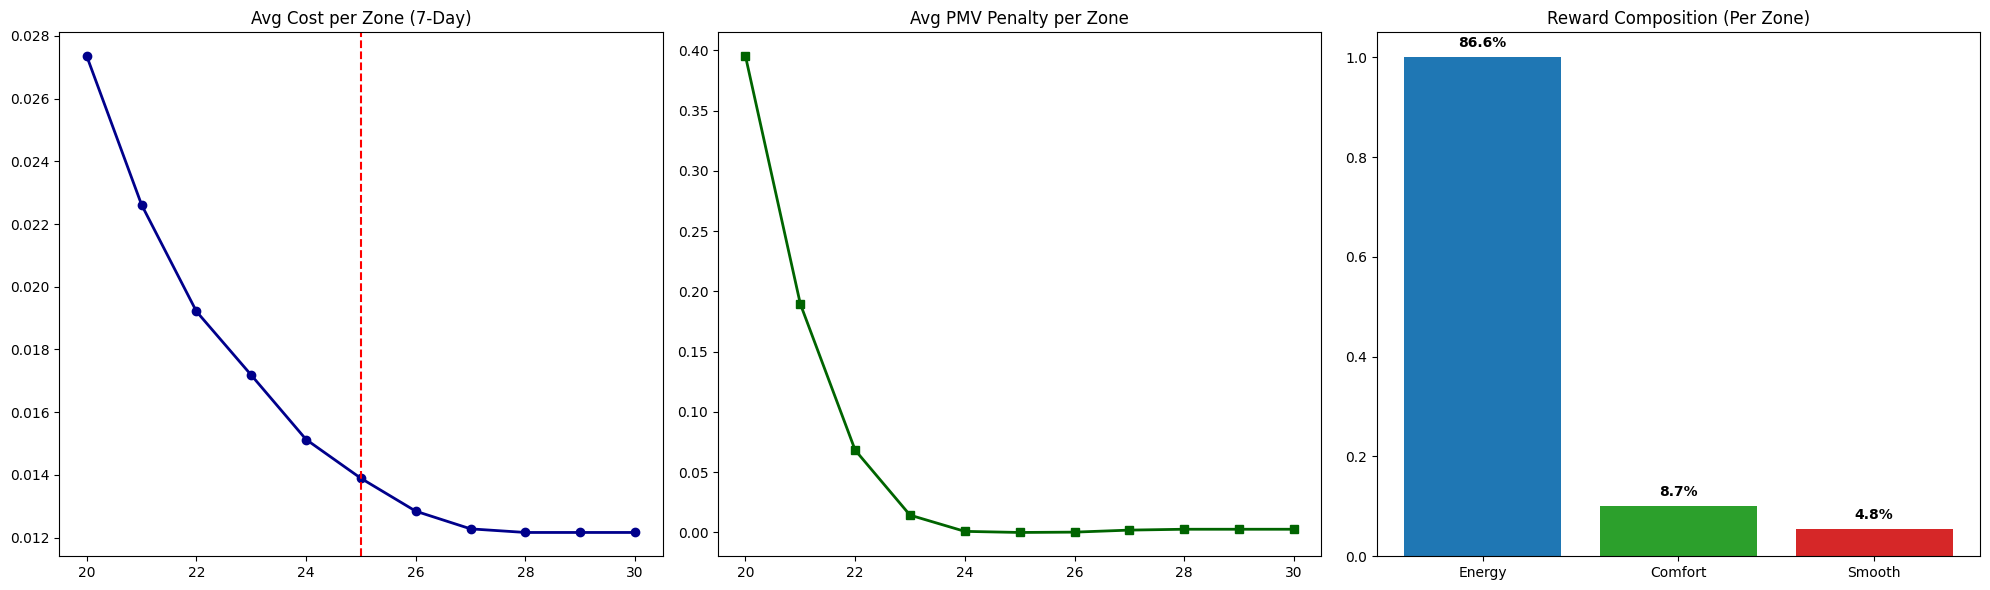

In [4]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

# 假设 config 对象已从 config_multizone_air.py 加载
# from config_multizone_air import config

try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    print("[!] 警告: 未找到 pythermalcomfort 库，PMV 将默认返回 0。")
    pmv_ppd_iso = None

class MultizoneAirScalerIdentifier:
    def __init__(self, config):
        self.config = config
        self.url = config.BOPTEST_URL
        self.case = config.CASE_NAME
        
        # 使用 Config 中定义的探测范围
        self.setpoint_range = np.arange(config.PROBING_LOW, config.PROBING_HIGH + 1.0, 1.0)
        
        self.results = []
        self.PROBING_STEPS = 96 * 7 
        self.NOISE_STD = 0.25 

    def _get_clo(self, t_out_c):
        params = self.config.PHYSICAL_CONFIG['clo_dynamic_params']
        if t_out_c < params['temp_low']: return params['winter_clo']
        if t_out_c > params['temp_high']: return params['summer_clo']
        ratio = (t_out_c - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

    def run_probing(self):
        print(f"[*] 启动 Multizone Air 5-Zone 系统标定 (Case: {self.case})")
        print(f"[*] 策略: 7天典型周 + 基于预报的占用判断")
        
        for sp in self.setpoint_range:
            print(f"    > 探测温度点: {sp} C ... ", end="", flush=True)
            
            res_sel = requests.post(f"{self.url}/testcases/{self.case}/select").json()
            tid = res_sel['testid']
            
            requests.put(f"{self.url}/scenario/{tid}", json={'electricity_price': 'dynamic'})
            requests.put(f"{self.url}/step/{tid}", json={'step': self.config.CONTROL_PERIOD})
            
            start_t = self.config.START_DAY * 24 * 3600
            requests.put(f"{self.url}/initialize/{tid}", json={
                'start_time': start_t, 
                'warmup_period': 7 * 24 * 3600
            }, timeout=600)
            
            point_data = []
            prev_u = np.full(5, sp)
            
            for step in range(self.PROBING_STEPS):
                noises = np.random.normal(0, self.NOISE_STD, size=5)
                u_noisy = sp + noises
                
                # 构建 10 维动作向量
                u_input = {
                    'hvac_oveZonSupCor_TZonCooSet_u': u_noisy[0] + 273.15, 'hvac_oveZonSupCor_TZonCooSet_activate': 1,
                    'hvac_oveZonSupCor_TZonHeaSet_u': self.config.FIXED_HEATING_SETPOINT, 'hvac_oveZonSupCor_TZonHeaSet_activate': 1,
                    'hvac_oveZonSupNor_TZonCooSet_u': u_noisy[1] + 273.15, 'hvac_oveZonSupNor_TZonCooSet_activate': 1,
                    'hvac_oveZonSupNor_TZonHeaSet_u': self.config.FIXED_HEATING_SETPOINT, 'hvac_oveZonSupNor_TZonHeaSet_activate': 1,
                    'hvac_oveZonSupSou_TZonCooSet_u': u_noisy[2] + 273.15, 'hvac_oveZonSupSou_TZonCooSet_activate': 1,
                    'hvac_oveZonSupSou_TZonHeaSet_u': self.config.FIXED_HEATING_SETPOINT, 'hvac_oveZonSupSou_TZonHeaSet_activate': 1,
                    'hvac_oveZonSupEas_TZonCooSet_u': u_noisy[3] + 273.15, 'hvac_oveZonSupEas_TZonCooSet_activate': 1,
                    'hvac_oveZonSupEas_TZonHeaSet_u': self.config.FIXED_HEATING_SETPOINT, 'hvac_oveZonSupEas_TZonHeaSet_activate': 1,
                    'hvac_oveZonSupWes_TZonCooSet_u': u_noisy[4] + 273.15, 'hvac_oveZonSupWes_TZonCooSet_activate': 1,
                    'hvac_oveZonSupWes_TZonHeaSet_u': self.config.FIXED_HEATING_SETPOINT, 'hvac_oveZonSupWes_TZonHeaSet_activate': 1
                }
                
                # 获取预报数据，用于提取当前步的真实占用人数
                forecast_res = requests.put(f"{self.url}/forecast/{tid}", 
                                             json={'point_names': self.config.FORECAST_POINTS, 
                                                   'horizon': 0, 'interval': self.config.CONTROL_PERIOD}).json()['payload']
                
                res_adv = requests.post(f"{self.url}/advance/{tid}", json=u_input).json()
                y = res_adv['payload']
                
                # 汇总全系统功率
                p_sys = (y.get('chi_reaPChi_y', 0) + y.get('heaPum_reaPHeaPum_y', 0) + 
                         y.get('hvac_reaAhu_PFanSup_y', 0) + y.get('chi_reaPPumDis_y', 0) + y.get('heaPum_reaPPumDis_y', 0))
                
                # 提取当前电价
                price = forecast_res['PriceElectricPowerDynamic'][0]
                cost_step = (p_sys * self.config.CONTROL_PERIOD / 3600000) * price
                
                # 计算 PMV 惩罚
                t_out = y['weaSta_reaWeaTDryBul_y'] - 273.15
                clo = self._get_clo(t_out)
                
                zone_keys = ['hvac_reaZonCor_TZon_y', 'hvac_reaZonNor_TZon_y', 'hvac_reaZonSou_TZon_y', 'hvac_reaZonEas_TZon_y', 'hvac_reaZonWes_TZon_y']
                occ_keys = ['Occupancy[cor]', 'Occupancy[nor]', 'Occupancy[sou]', 'Occupancy[eas]', 'Occupancy[wes]']
                
                penalties = []
                for i in range(5):
                    # 直接从预报数据中获取当前区域人数 (Occupancy > 0 视为有人)
                    num_ppl = forecast_res[occ_keys[i]][0]
                    pmv = 0
                    if pmv_ppd_iso and num_ppl > 0:
                        t_z = y.get(zone_keys[i], 298.15)
                        res = pmv_ppd_iso(tdb=t_z-273.15, tr=t_z-273.15, vr=0.1, rh=50, met=1.1, clo=clo)
                        pmv = res['pmv'] if isinstance(res, dict) else res.pmv
                    penalties.append(max(0, abs(pmv) - 0.5)**2)
                
                abs_du_total = sum(abs(u_noisy - prev_u))
                prev_u = u_noisy
                
                point_data.append({'cost': cost_step, 'pmv_p': sum(penalties), 'abs_du': abs_du_total})
            
            self.results.append({
                'temp': sp,
                'avg_cost': np.mean([d['cost'] for d in point_data]),
                'avg_pmv_p': np.mean([d['pmv_p'] for d in point_data]),
                'avg_abs_du': np.mean([d['abs_du'] for d in point_data])
            })
            requests.put(f"{self.url}/stop/{tid}")
            print(f"完成")

    def calculate_scalers(self):
        df = pd.DataFrame(self.results)
        n = self.config.N_ZONES
        rbc_row = df[df['temp'] == 25.0].iloc[0]
        
        avg_cost_per_zone = rbc_row['avg_cost'] / n
        s_energy = 1.0 / avg_cost_per_zone if avg_cost_per_zone > 0 else 1.0
        s_comfort = (s_energy * (0.10 * avg_cost_per_zone)) / 0.01
        
        # 统一使用目标理想预算 (5% 为动作平滑项)
        total_ideal_budget_per_zone = (s_energy * avg_cost_per_zone) + (s_comfort * 0.01)
        avg_abs_du_per_zone = rbc_row['avg_abs_du'] / n
        s_smooth = (0.05 * total_ideal_budget_per_zone) / avg_abs_du_per_zone if avg_abs_du_per_zone > 0 else 1.0
        
        return s_energy, s_comfort, s_smooth, df

    def plot_results(self, df, s_en, s_cm, s_sm):
        # 绘图逻辑保持一致...
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        n = self.config.N_ZONES
        axes[0].plot(df['temp'], df['avg_cost'] / n, 'o-', color='darkblue', linewidth=2)
        axes[0].axvline(25.0, color='red', linestyle='--', label='RBC (25C)')
        axes[0].set_title("Avg Cost per Zone (7-Day)", fontsize=12)
        axes[1].plot(df['temp'], df['avg_pmv_p'] / n, 's-', color='darkgreen', linewidth=2)
        axes[1].set_title("Avg PMV Penalty per Zone", fontsize=12)
        
        rbc_row = df[df['temp'] == 25.0].iloc[0]
        v_en = (rbc_row['avg_cost'] / n) * s_en
        v_cm = 0.01 * s_cm
        v_sm = (rbc_row['avg_abs_du'] / n) * s_sm
        values = [v_en, v_cm, v_sm]
        axes[2].bar(['Energy', 'Comfort', 'Smooth'], values, color=['#1f77b4', '#2ca02c', '#d62728'])
        axes[2].set_title("Reward Composition (Per Zone)", fontsize=12)
        total = sum(values)
        for i, v in enumerate(values):
            axes[2].text(i, v + 0.02, f"{(v/total)*100:.1f}%", ha='center', fontweight='bold')
        plt.tight_layout()
        plt.savefig("calibration_multizone_air_5zone.png", dpi=300)
        plt.show()

if __name__ == "__main__":
    identifier = MultizoneAirScalerIdentifier(config)
    identifier.run_probing()
    s_en, s_cm, s_sm, df = identifier.calculate_scalers()
    print(f"\nSCALER_ENERGY: {s_en:.6f}\nSCALER_COMFORT: {s_cm:.6f}\nSCALER_SMOOTH: {s_sm:.6f}")
    identifier.plot_results(df, s_en, s_cm, s_sm)

# RBC

[系统] pythermalcomfort 已成功加载。
[multizone_office_simple_air] 启动 5-Zone Air RBC 验证运行...
    > 起始日: 199 | 时长: 7 天 | 步数: 672
    > TestID: 18a2f337-256f-4280-a8ec-f773b7f1fb05
    > Step 0/672 | Reward: -0.31 | P_Total: 2958.8W
    > Step 96/672 | Reward: -0.32 | P_Total: 5874.6W
    > Step 192/672 | Reward: -0.10 | P_Total: 1906.1W
    > Step 288/672 | Reward: -0.08 | P_Total: 1488.3W
    > Step 384/672 | Reward: -0.00 | P_Total: 1.5W
    > Step 480/672 | Reward: -0.32 | P_Total: 5938.8W
    > Step 576/672 | Reward: -0.36 | P_Total: 6706.9W

[成功] RBC 数据已保存: multizone_office_simple_air_residual_transfer\data_rbc/rbc_validation_air_5zone.csv

      RBC PERFORMANCE REPORT (5-ZONE AIR)      
7天总成本        : $180.36
舒适度违规比例    : 2/1904 区域·步
系统平均功率      : 9994.94 W


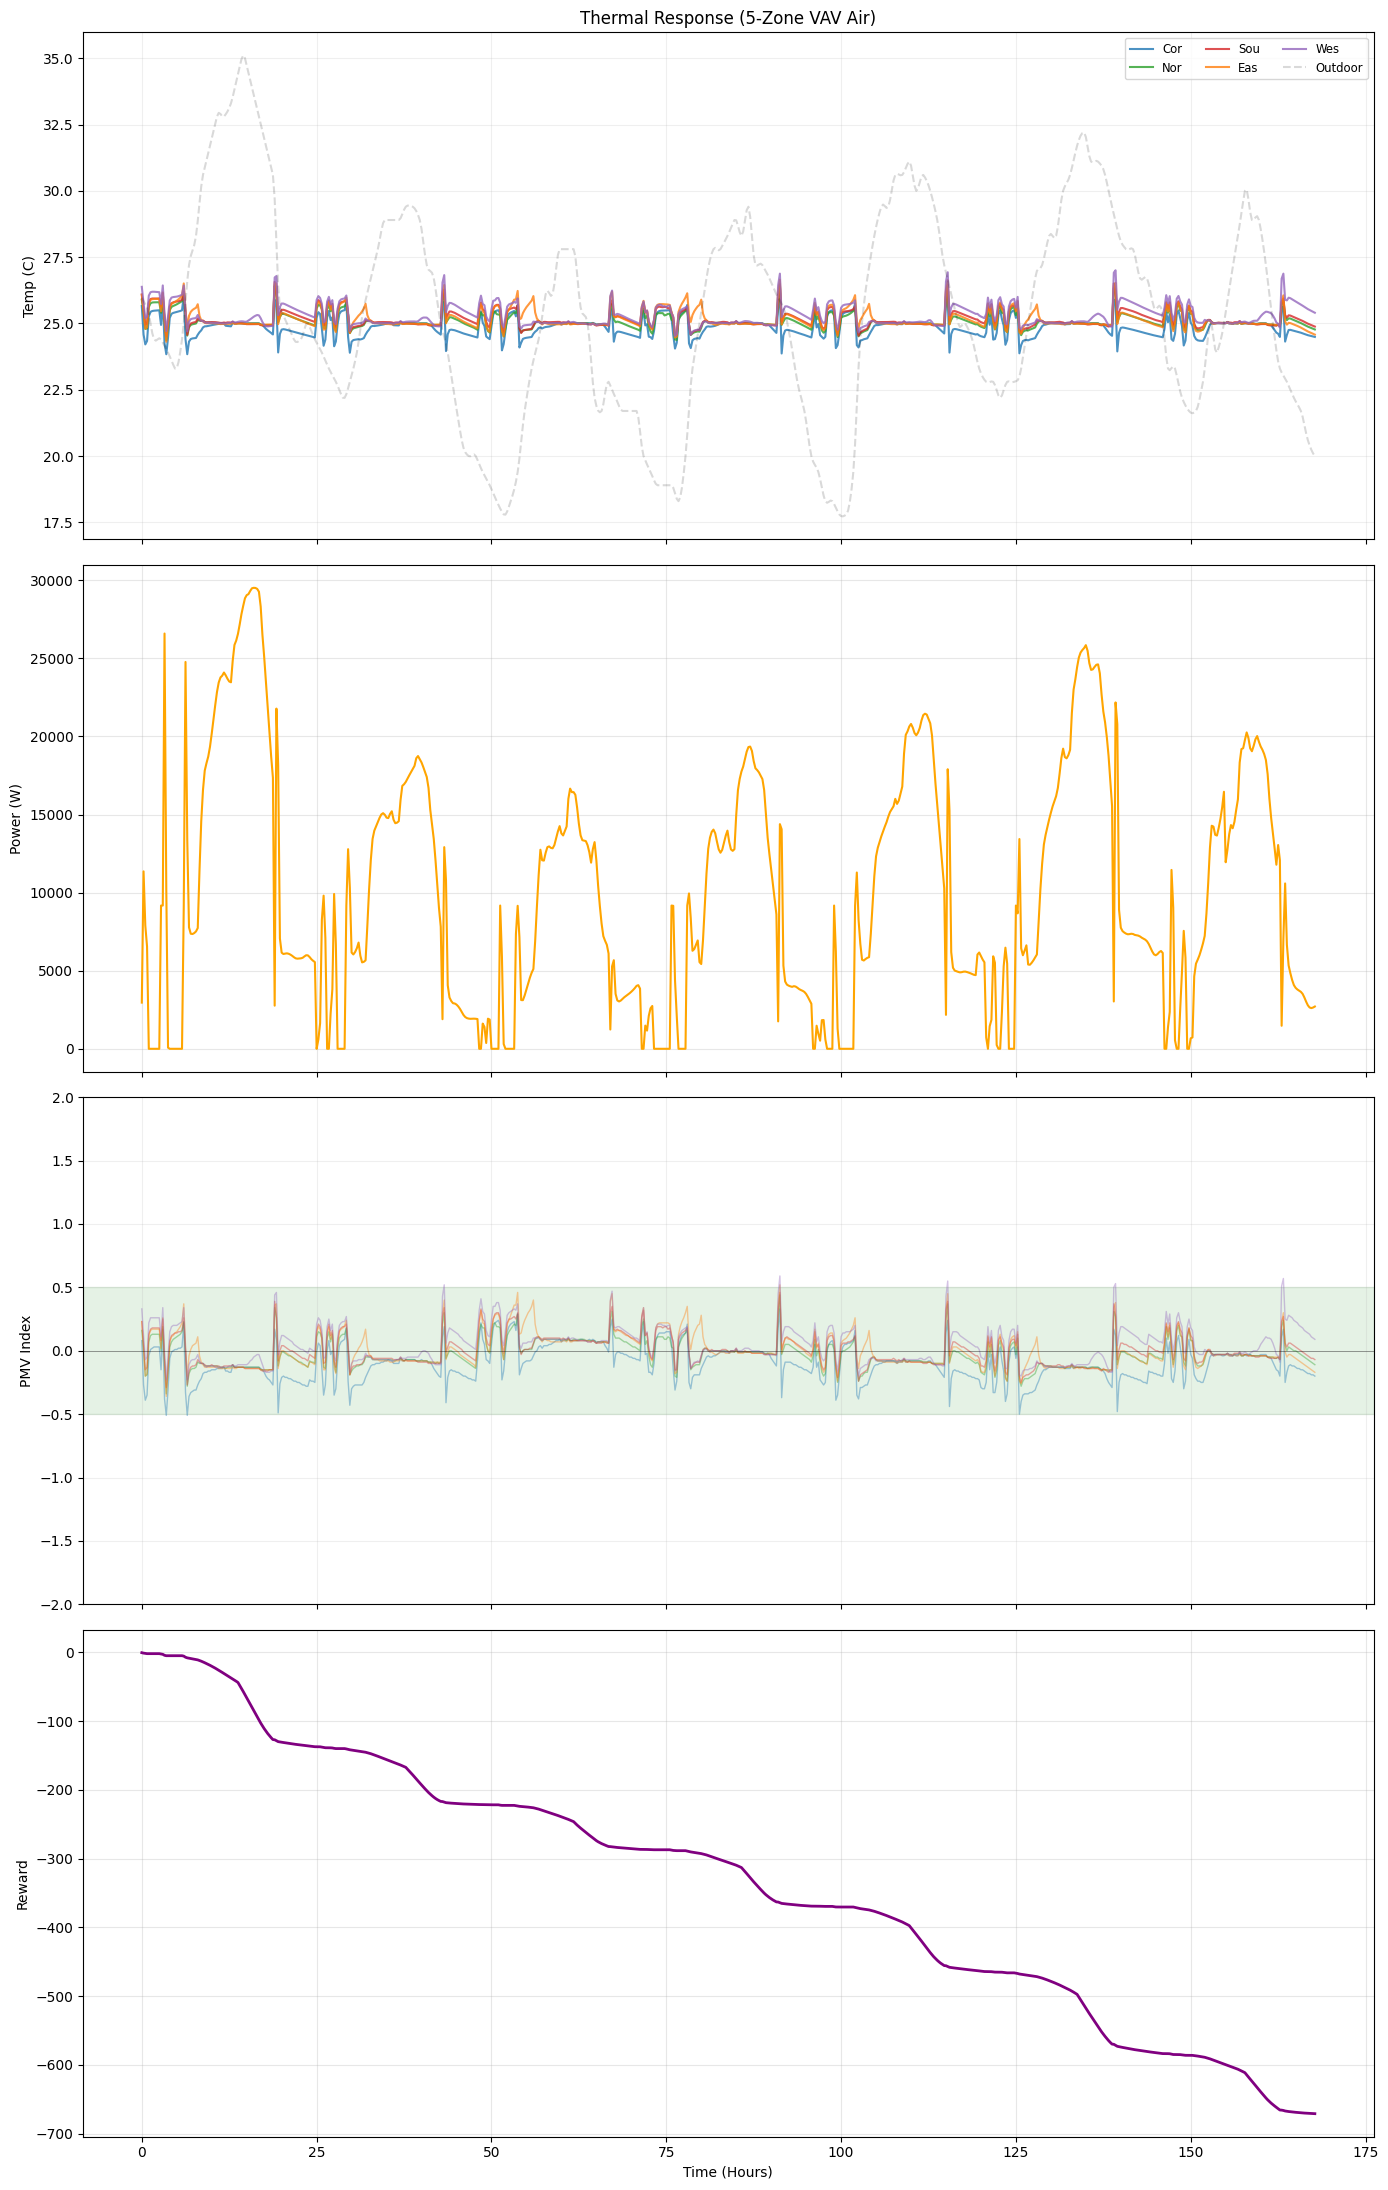

In [5]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import traceback
from collections import deque

# 导入物理计算库
try:
    from pythermalcomfort.models import pmv_ppd_iso
    print("[系统] pythermalcomfort 已成功加载。")
except ImportError:
    print("[警告] 未找到 pythermalcomfort。PMV 将默认为 0。")
    pmv_ppd_iso = None

# --- 工具函数：鲁棒请求 ---
def retry_request(method, url, max_retries=5, delay=1.0, **kwargs):
    for i in range(max_retries):
        try:
            resp = requests.request(method, url, **kwargs)
            resp.raise_for_status()
            if method.lower() == 'put' and 'stop' in url: return {'status': 'stopped'}
            return resp.json()
        except Exception as e:
            if i == max_retries - 1:
                print(f"[错误] 请求失败 ({max_retries} 次尝试): {url}")
                raise e
            time.sleep(delay * (2 ** i))

# --- 工具函数：物理计算 ---
def calc_pmv(t_air_k, phys_config, clo):
    if pmv_ppd_iso is None: return 0.0
    t_c = t_air_k - 273.15
    try:
        res = pmv_ppd_iso(
            tdb=t_c, tr=t_c, vr=phys_config['air_velocity'],
            rh=phys_config['relative_humidity'], met=phys_config['metabolic_rate'], clo=clo
        )
        return res['pmv'] if isinstance(res, dict) else res.pmv
    except: return 0.0

def get_clo(t_out_c, params):
    if t_out_c < params['temp_low']: return params['winter_clo']
    if t_out_c > params['temp_high']: return params['summer_clo']
    ratio = (t_out_c - params['temp_low']) / (params['temp_high'] - params['temp_low'])
    return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

# ==============================================================================
# 主执行程序
# ==============================================================================
def run_rbc_5zone_air_validation():
    # 1. 设置时间 (验证周：起始日 + 7天)
    VAL_START_DAY = config.START_DAY + 7 
    start_time = VAL_START_DAY * 24 * 3600
    duration = 7 * 24 * 3600
    steps = int(duration / config.CONTROL_PERIOD)
    
    zones = ['cor', 'nor', 'sou', 'eas', 'wes']
    
    print(f"[{config.CASE_NAME}] 启动 5-Zone Air RBC 验证运行...")
    print(f"    > 起始日: {VAL_START_DAY} | 时长: 7 天 | 步数: {steps}")

    testid = None
    try:
        # 2. 初始化 BOPTEST
        sel_res = retry_request('post', f'{config.BOPTEST_URL}/testcases/{config.CASE_NAME}/select')
        testid = sel_res['testid']
        print(f"    > TestID: {testid}")
        
        retry_request('put', f'{config.BOPTEST_URL}/scenario/{testid}', json={'electricity_price': 'dynamic'})
        retry_request('put', f'{config.BOPTEST_URL}/step/{testid}', json={'step': config.CONTROL_PERIOD})
        
        # 初始化并预热 7 天
        init_res = retry_request('put', f'{config.BOPTEST_URL}/initialize/{testid}', 
                                 json={'start_time': start_time, 'warmup_period': 7*24*3600})
        y_current = init_res['payload']
        
        # 3. 历史队列 (用于模拟 DRL 观测空间)
        # 修正：根据文档使用 hvac_reaZon{z}_TZon_y
        h_temp = {z: deque([y_current[f'hvac_reaZon{z.capitalize()}_TZon_y']]*4, maxlen=4) for z in zones}
        # 系统总功率历史
        h_power = deque([0.0]*4, maxlen=4)
        # 5 区域动作历史 (开尔文)
        h_act = {z: deque([config.BASE_COOLING_SETPOINT]*4, maxlen=4) for z in zones}
        
        # 4. 仿真循环
        data_log = []
        total_cost = 0.0
        occupied_steps = 0
        comfort_viol_steps = 0
        current_clo = 0.5
        prev_day_idx = -1
        
        for i in range(steps):
            time_now = y_current['time']
            
            # --- A. 更新服装热阻 (每日更新) ---
            day_idx = int(time_now // 86400)
            if day_idx != prev_day_idx:
                f_res = retry_request('put', f'{config.BOPTEST_URL}/forecast/{testid}', 
                                     json={'point_names':['TDryBul'], 'horizon':86400, 'interval':3600})
                daily_mean = np.mean(f_res['payload']['TDryBul']) - 273.15
                current_clo = get_clo(daily_mean, config.PHYSICAL_CONFIG['clo_dynamic_params'])
                prev_day_idx = day_idx

            # --- B. 获取预报 (所有区域的占用情况) ---
            f_res = retry_request('put', f'{config.BOPTEST_URL}/forecast/{testid}', 
                                 json={'point_names': config.FORECAST_POINTS, 
                                       'horizon': 4*config.CONTROL_PERIOD, 
                                       'interval': config.CONTROL_PERIOD})
            forecast = f_res['payload']
            
            price_elec = forecast['PriceElectricPowerDynamic'][0] or 0.0
            
            # --- C. RBC 逻辑与动作构造 ---
            u = {}
            active_zones_mask = []
            u['hvac_oveAhu_TSupSet_u'] = 290.15         # 17°C
            u['hvac_oveAhu_TSupSet_activate'] = 1
            
            for z in zones:
                occ_key = f'Occupancy[{z}]'
                occ_val = forecast[occ_key][0] if forecast[occ_key][0] is not None else 0.0
                is_occupied = occ_val > 0
                active_zones_mask.append(int(is_occupied))
                
                # 基准策略：有人 25C / 无人 30C
                set_cool_c = 25.0 if is_occupied else 30.0
                set_cool_k = set_cool_c + 273.15
                
                # 构造输入 (符合文档：hvac_oveZonSup{Z}_TZonCooSet_u)
                u[f'hvac_oveZonSup{z.capitalize()}_TZonCooSet_u'] = set_cool_k
                u[f'hvac_oveZonSup{z.capitalize()}_TZonCooSet_activate'] = 1
                u[f'hvac_oveZonSup{z.capitalize()}_TZonHeaSet_u'] = config.FIXED_HEATING_SETPOINT
                u[f'hvac_oveZonSup{z.capitalize()}_TZonHeaSet_activate'] = 1
                
                # 保存动作到历史 (用于平滑度)
                h_act[z].append(set_cool_k)

            # --- D. 执行动作 ---
            res_step = retry_request('post', f'{config.BOPTEST_URL}/advance/{testid}', json=u)
            y_next = res_step['payload']
            
            # --- E. 指标计算与归一化 ---
            # 修正：聚合所有电力消耗点位
            p_total = (y_next.get('chi_reaPChi_y', 0) + 
                       y_next.get('chi_reaPPumDis_y', 0) + 
                       y_next.get('heaPum_reaPHeaPum_y', 0) + 
                       y_next.get('heaPum_reaPPumDis_y', 0) + 
                       y_next.get('hvac_reaAhu_PFanSup_y', 0) + 
                       y_next.get('hvac_reaAhu_PPumCoo_y', 0) + 
                       y_next.get('hvac_reaAhu_PPumHea_y', 0))
            
            step_cost = (p_total * config.SAMPLING_PERIOD / 3600000.0) * price_elec
            total_cost += step_cost
            
            # 计算 5 个区域的 PMV 和惩罚
            total_pmv_p = 0.0
            pmv_values = {}
            for idx, z in enumerate(zones):
                # 修正：点位名称 hvac_reaZon{Z}_TZon_y
                t_zone_k = y_next[f'hvac_reaZon{z.capitalize()}_TZon_y']
                pmv = calc_pmv(t_zone_k, config.PHYSICAL_CONFIG, current_clo)
                pmv_values[z] = pmv
                
                # 舒适度惩罚 (仅在有人时计算)
                if active_zones_mask[idx] == 1:
                    penalty = max(0, abs(pmv) - 0.5)**2
                    total_pmv_p += penalty
                    occupied_steps += 1
                    if penalty > 0: comfort_viol_steps += 1
            
            # 动作跳变汇总 (L1)
            total_delta_u = sum([abs(h_act[z][-1] - h_act[z][-2]) for z in zones])
            
            # 统一奖励逻辑 (单区域归一化)
            n_z = config.N_ZONES
            w = config.REWARD_WEIGHTS
            term_en = w['scaler_energy'] * (step_cost / n_z)
            term_cm = w['scaler_comfort'] * (total_pmv_p / n_z)
            term_sm = w['scaler_smooth'] * (total_delta_u / n_z)
            
            total_reward = - (w['w_energy'] * term_en + w['w_comfort'] * term_cm + w['w_smooth'] * term_sm)

            # --- F. 记录数据 (用于训练对齐) ---
            row = {
                'time': time_now,
                'obs_sin_time': np.sin(2 * np.pi * (time_now % 86400) / 86400),
                'obs_cos_time': np.cos(2 * np.pi * (time_now % 86400) / 86400),
                'temp_out': y_next['weaSta_reaWeaTDryBul_y'] - 273.15,
                'power_total': p_total,
                'cost': step_cost,
                'reward': total_reward,
                'is_any_occupied': int(any(active_zones_mask))
            }
            # 记录各区域物理状态与观测历史
            for z in zones:
                row[f'temp_{z}'] = y_next[f'hvac_reaZon{z.capitalize()}_TZon_y'] - 273.15
                row[f'pmv_{z}'] = pmv_values[z]
                row[f'setpoint_{z}'] = u[f'hvac_oveZonSup{z.capitalize()}_TZonCooSet_u'] - 273.15
                # 对齐 Config.OBSERVATION_COLUMNS 命名规范 (obs_T_{z}_p1 ... p4)
                for p_idx in range(1, 5):
                    row[f'obs_T_{z}_p{p_idx}'] = h_temp[z][-p_idx] - 273.15
            
            data_log.append(row)
            
            # 更新状态队列
            for z in zones: h_temp[z].append(y_next[f'hvac_reaZon{z.capitalize()}_TZon_y'])
            h_power.append(p_total)
            y_current = y_next
            
            if i % 96 == 0: print(f"    > Step {i}/{steps} | Reward: {total_reward:.2f} | P_Total: {p_total:.1f}W")

        # 5. 保存结果
        df = pd.DataFrame(data_log)
        csv_path = os.path.join(config.LOG_DIRS['data_rbc'], 'rbc_validation_air_5zone.csv')
        df.to_csv(csv_path, index=False)
        print(f"\n[成功] RBC 数据已保存: {csv_path}")
        
        # --- 性能报告 ---
        print("\n" + "="*50)
        print("      RBC PERFORMANCE REPORT (5-ZONE AIR)      ")
        print("="*50)
        print(f"7天总成本        : ${total_cost:.2f}")
        print(f"舒适度违规比例    : {comfort_viol_steps}/{occupied_steps} 区域·步")
        print(f"系统平均功率      : {df['power_total'].mean():.2f} W")
        print("="*50)
        
        # --- 绘图 (4 面板标准) ---
        fig, axes = plt.subplots(4, 1, figsize=(14, 22), sharex=True)
        time_h = np.arange(len(df)) * config.CONTROL_PERIOD / 3600
        
        # Ax1: 5 区域温度轨迹
        colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd']
        for idx, z in enumerate(zones):
            axes[0].plot(time_h, df[f'temp_{z}'], label=f'{z.capitalize()}', color=colors[idx], alpha=0.8)
        axes[0].plot(time_h, df['temp_out'], label='Outdoor', color='black', alpha=0.15, linestyle='--')
        axes[0].set_ylabel('Temp (C)')
        axes[0].legend(loc='upper right', ncol=3, fontsize='small')
        axes[0].set_title('Thermal Response (5-Zone VAV Air)')
        axes[0].grid(True, alpha=0.2)

        # Ax2: 系统聚合总功率
        axes[1].plot(time_h, df['power_total'], label='Total HVAC Power', color='orange')
        axes[1].set_ylabel('Power (W)')
        axes[1].grid(True, alpha=0.3)

        # Ax3: 5 区域 PMV 舒适度
        for idx, z in enumerate(zones):
            axes[2].plot(time_h, df[f'pmv_{z}'], color=colors[idx], alpha=0.4, linewidth=1)
        axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.1, label='Comfort Zone')
        axes[2].set_ylabel('PMV Index')
        axes[2].set_ylim(-2, 2)
        axes[2].axhline(0, color='black', linewidth=0.5, alpha=0.5)
        axes[2].grid(True, alpha=0.2)

        # Ax4: 累计综合奖励
        axes[3].plot(time_h, df['reward'].cumsum(), label='RBC Cumulative Reward', color='purple', linewidth=2)
        axes[3].set_ylabel('Reward')
        axes[3].set_xlabel('Time (Hours)')
        axes[3].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(config.LOG_DIRS['results_comparison'], 'rbc_validation_air_plot.png'))
        plt.show()

    except Exception as e:
        print(f"\n[严重错误] {e}")
        traceback.print_exc()
    finally:
        if testid: retry_request('put', f'{config.BOPTEST_URL}/stop/{testid}')

if __name__ == '__main__':
    run_rbc_5zone_air_validation()

# DRL

In [ ]:
import os
import gymnasium as gym
import torch
import requests
import pandas as pd
import numpy as np
import time
import traceback
import json
import gc
import subprocess
import shlex
import sys
import math
import matplotlib.pyplot as plt
from collections import deque
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

# 引入物理计算库
try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

# ==============================================================================
# 1. 核心辅助类与工具函数 (工程健壮性升级)
# ==============================================================================

def global_linear_schedule(initial_value):
    """学习率线性衰减调度器"""
    def func(progress_remaining):
        return initial_value * (0.9 * progress_remaining + 0.1)
    return func

def safe_float(val, default=0.0):
    try:
        if val is None: return default
        f = float(val)
        return f if not (math.isnan(f) or math.isinf(f)) else default
    except: return default

def _make_request_with_retry(method, url, rank, context_msg, max_retries=5, **kwargs):
    """带指数退避和错误过滤的健壮请求"""
    for attempt in range(max_retries):
        try:
            kwargs.setdefault('timeout', 90)
            response = requests.request(method, url, **kwargs)
            if response.status_code == 200:
                return response.json() if response.content else {'status': 'success'}
            # 忽略重复停止导致的 400 错误
            if response.status_code == 400 and "stop" in url:
                return {'status': 'ignored_error'}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 * (attempt + 1))
            else:
                print(f"[Rank {rank}] {context_msg} 最终失败: {e}")
    return None

def get_dynamic_clo(daily_mean_tout, params):
    """动态服装热阻计算逻辑"""
    t = safe_float(daily_mean_tout, 20.0)
    if t < params['temp_low']: return params['winter_clo']
    elif t > params['temp_high']: return params['summer_clo']
    else:
        ratio = (t - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

def calculate_pmv_state(t_air_k, phys_config, clo_val):
    """
    高度鲁棒的 PMV 计算函数：
    1. 自动适配不同的字典键名 (air_velocity vs vr 等)
    2. 自动适配库返回对象类型
    3. 发生错误时打印一次具体原因
    """
    if pmv_ppd_iso is None: return 0.0
    
    # 物理量提取 (带容错)
    t_c = safe_float(t_air_k, 298.15) - 273.15
    # 自动映射键名，防止 Config 中的命名差异
    vel = phys_config.get('air_velocity', phys_config.get('vr', 0.1))
    rh = phys_config.get('relative_humidity', phys_config.get('rh', 50.0))
    met = phys_config.get('metabolic_rate', phys_config.get('met', 1.1))
    clo = safe_float(clo_val, 0.5)

    try:
        res = pmv_ppd_iso(tdb=t_c, tr=t_c, vr=vel, rh=rh, met=met, clo=clo)
        
        # 鲁棒提取结果
        if isinstance(res, dict):
            val = res.get('pmv', 0.0)
        elif hasattr(res, 'pmv'):
            val = res.pmv
        else:
            val = float(res) # 部分版本直接返回标量
            
        return safe_float(val, 0.0)
    except Exception as e:
        # 只在第一次出错时提醒，避免刷屏
        if not hasattr(calculate_pmv_state, "_already_failed"):
            print(f"\n[PMV 运行时错误] 输入: T={t_c:.2f}, Clo={clo:.2f} | 原因: {e}")
            calculate_pmv_state._already_failed = True
        return 0.0

class ForecastProvider:
    """预取预测数据辅助类：针对 2 区域进行扩展"""
    def __init__(self, config_obj):
        self.config = config_obj
        self.data = {}
        self.start_time = config_obj.START_DAY * 24 * 3600
        self.total_horizon = (config_obj.RBC_COLLECT_DAYS + 1) * 24 * 3600 

    def prefetch_all(self):
        print(f"\n[ForecastProvider] 正在预取全量数据 (Horizon: {self.total_horizon/3600:.1f}h)...")
        try:
            sel_url = f"{self.config.BOPTEST_URL}/testcases/{self.config.CASE_NAME}/select"
            res_sel = requests.post(sel_url, timeout=60).json()
            tid = res_sel['testid']
            
            requests.put(f"{self.config.BOPTEST_URL}/scenario/{tid}", json={'electricity_price': 'dynamic'})
            requests.put(f"{self.config.BOPTEST_URL}/initialize/{tid}", 
                         json={'start_time': self.start_time, 'warmup_period': 0})
            
            f_payload = {
                'point_names': self.config.FORECAST_POINTS,
                'horizon': self.total_horizon,
                'interval': self.config.CONTROL_PERIOD
            }
            res_f = requests.put(f"{self.config.BOPTEST_URL}/forecast/{tid}", json=f_payload, timeout=120).json()
            
            if 'payload' in res_f:
                self.data = {k: np.array([x if x is not None else 0.0 for x in v]) 
                             for k, v in res_f['payload'].items()}
                print(f"[ForecastProvider] 预取成功。点位: {list(self.data.keys())}")
            
            requests.put(f"{self.config.BOPTEST_URL}/stop/{tid}")
        except Exception as e:
            print(f"[ForecastProvider] 预取失败: {e}")
            raise e

    def get_local_forecast(self, current_time, point_name, horizon_steps=5):
        rel_time = current_time - self.start_time
        idx = int(max(0, rel_time // self.config.CONTROL_PERIOD))
        full_series = self.data.get(point_name)
        if full_series is None: return np.zeros(horizon_steps)
        vals = full_series[idx : idx + horizon_steps]
        if len(vals) < horizon_steps:
            padding = [vals[-1]] * (horizon_steps - len(vals)) if len(vals) > 0 else [0.0] * horizon_steps
            vals = np.concatenate([vals, padding])
        return vals

# ==============================================================================
# 1. 5-Zone Air 环境类封装 (残差控制 + 5区域映射)
# ==============================================================================

class Air5ZoneResidualEnv(gym.Env):
    def __init__(self, config_obj, forecast_provider, is_validation=False, rank=0):
        super().__init__()
        self.config, self.fp, self.rank = config_obj, forecast_provider, rank
        self.url = self.config.BOPTEST_URL
        self.zones = ['cor', 'nor', 'sou', 'eas', 'wes']
        
        start_day = self.config.START_DAY + 7 if is_validation else self.config.START_DAY
        self.start_time = start_day * 24 * 3600
        self.max_episode_steps = int(7 * 24 * 3600 / self.config.CONTROL_PERIOD)
        
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(5,), dtype=np.float32)
        
        # 建立观测空间边界
        lows, highs = [], []
        for col in self.config.OBSERVATION_COLUMNS:
            base_key = 'T' if '_T_' in col else 'Price' if 'Price' in col else \
                       'Occ' if 'OccMask' in col else 'HGloHor' if 'HGloHor' in col else \
                       'TDryBul' if 'TDryBul' in col else 'pow' if 'power_norm' in col else \
                       'pmv' if 'pmv' in col else 'act' if 'act' in col else col.replace('obs_', '')
            r = self.config.OBSERVATIONS_CONFIG.get(base_key, (0.0, 1.0))
            lows.append(r[0]); highs.append(r[1])
        self.observation_space = gym.spaces.Box(low=np.array(lows, dtype=np.float32), 
                                                high=np.array(highs, dtype=np.float32), dtype=np.float32)
        
        self.testid = None
        self.history_temp = {z: deque(maxlen=5) for z in self.zones}
        self.history_act = {z: deque(maxlen=5) for z in self.zones}
        self.history_power = deque(maxlen=5)
        self.current_pmv = {z: 0.0 for z in self.zones}
        self.current_clo = 0.5 # 初始值

    def _get_observations(self, y):
        cur_t = y.get('time', self.start_time)
        raw = {'obs_sin_time': np.sin(2*np.pi*(cur_t%86400)/86400), 'obs_cos_time': np.cos(2*np.pi*(cur_t%86400)/86400)}
        
        for z in self.zones:
            z_cap = z.capitalize()
            raw[f'obs_T_{z}'] = y.get(f'hvac_reaZon{z_cap}_TZon_y', 298.15)
            for i in range(1, 5):
                raw[f'obs_T_{z}_p{i}'] = self.history_temp[z][-i] if len(self.history_temp[z])>=i else 298.15
            raw[f'obs_pmv_{z}'] = self.current_pmv[z]
            raw[f'obs_act_{z}_p1'] = self.history_act[z][-1] if len(self.history_act[z])>0 else 298.15
            occ_vals = self.fp.get_local_forecast(cur_t, f'Occupancy[{z}]', 5)
            for i in range(5): raw[f'obs_OccMask_{z}_{i}'] = 1.0 if occ_vals[i] > 0 else 0.0

        for i in range(1, 5):
            raw[f'obs_power_norm_p{i}'] = (self.history_power[-i]/self.config.MAX_SYSTEM_POWER) if len(self.history_power)>=i else 0.0
        
        for p in ['TDryBul', 'HGloHor', 'PriceElectricPowerDynamic']:
            vals = self.fp.get_local_forecast(cur_t, p, 5)
            p_map = 'Price' if 'Price' in p else p
            for i in range(5): raw[f'obs_{p_map}_{i}'] = vals[i]
        return np.array([raw.get(c, 0.0) for c in self.config.OBSERVATION_COLUMNS], dtype=np.float32)

    def reset(self, seed=None, options=None):
        if self.testid is None:
            res = requests.post(f"{self.url}/testcases/{self.config.CASE_NAME}/select").json()
            self.testid = res['testid']
            requests.put(f"{self.url}/step/{self.testid}", json={'step': self.config.CONTROL_PERIOD})
            requests.put(f"{self.url}/scenario/{self.testid}", json={'electricity_price': 'dynamic'})
            
        res_init = requests.put(f"{self.url}/initialize/{self.testid}", 
                                json={'start_time': self.start_time, 'warmup_period': 7*24*3600}).json()
        y = res_init['payload']
        self.current_step = 0
        self.history_power.clear(); self.history_power.append(0.0)
        
        # 修正：正确循环初始化所有区域的历史
        for z in self.zones:
            self.history_temp[z].clear()
            self.history_act[z].clear()
            z_cap = z.capitalize()
            self.history_temp[z].append(y.get(f'hvac_reaZon{z_cap}_TZon_y', 298.15))
            self.history_act[z].append(298.15)
            self.current_pmv[z] = 0.0

        return self._get_observations(y), {}

    def step(self, action_norm):
        cur_t = self.start_time + self.current_step * self.config.CONTROL_PERIOD
        
        # A. 更新热阻 (每日)
        if self.current_step % 96 == 0:
            tout_f = self.fp.get_local_forecast(cur_t, 'TDryBul', 96)
            self.current_clo = get_dynamic_clo(np.mean(tout_f)-273.15, self.config.PHYSICAL_CONFIG['clo_dynamic_params'])

        # B. 5区域动作映射：固定 25C (298.15K) 基准 + 残差
        absolute_base_k = 298.15
        u = {}
        u['hvac_oveAhu_TSupSet_u'] = 290.15     # 17°C
        u['hvac_oveAhu_TSupSet_activate'] = 1
        target_sets_k = []
        for i, z in enumerate(self.zones):
            z_cap = z.capitalize()
            set_k = np.clip(absolute_base_k + float(action_norm[i]) * self.config.RESIDUAL_ACTION_SCALE, 293.15, 303.15)
            u[f'hvac_oveZonSup{z_cap}_TZonCooSet_u'] = set_k
            u[f'hvac_oveZonSup{z_cap}_TZonCooSet_activate'] = 1
            u[f'hvac_oveZonSup{z_cap}_TZonHeaSet_u'] = self.config.FIXED_HEATING_SETPOINT
            u[f'hvac_oveZonSup{z_cap}_TZonHeaSet_activate'] = 1
            target_sets_k.append(set_k)

        # C. 环境推进
        res = _make_request_with_retry('post', f"{self.url}/advance/{self.testid}", self.rank, "adv", json=u)
        y_next = res['payload']
        
        # D. 聚合功率 (5-Zone Case 必修课)
        p_tot = (y_next.get('chi_reaPChi_y', 0) + y_next.get('chi_reaPPumDis_y', 0) + 
                 y_next.get('heaPum_reaPHeaPum_y', 0) + y_next.get('heaPum_reaPPumDis_y', 0) + 
                 y_next.get('hvac_reaAhu_PFanSup_y', 0) + y_next.get('hvac_reaAhu_PPumCoo_y', 0) + 
                 y_next.get('hvac_reaAhu_PPumHea_y', 0))
        
        price = self.fp.get_local_forecast(cur_t, 'PriceElectricPowerDynamic', 1)[0]
        cost = (p_tot * self.config.CONTROL_PERIOD / 3600000.0) * price
        
        # E. 奖励计算 (单区域归一化 / 5.0)
        w, n = self.config.REWARD_WEIGHTS, self.config.N_ZONES # n=5.0
        en_penalty = (cost / n) * w['scaler_energy']
        
        cm_total_penalty = 0.0
        sm_total_penalty = 0.0
        for i, z in enumerate(self.zones):
            # PMV
            tk = y_next[f'hvac_reaZon{z.capitalize()}_TZon_y']
            self.current_pmv[z] = calculate_pmv_state(tk, self.config.PHYSICAL_CONFIG, self.current_clo)
            # 仅在有人时罚款
            occ = self.fp.get_local_forecast(cur_t, f'Occupancy[{z}]', 1)[0]
            if occ > 0:
                cm_total_penalty += max(0, abs(self.current_pmv[z]) - 0.4)**2
            # 平滑度
            sm_total_penalty += abs(target_sets_k[i] - self.history_act[z][-1]) if len(self.history_act[z])>0 else 0
            
            # 更新历史
            self.history_temp[z].append(tk)
            self.history_act[z].append(target_sets_k[i])

        reward = -1.0 * (w['w_energy'] * en_penalty + 
                         w['w_comfort'] * (cm_total_penalty / n) * w['scaler_comfort'] + 
                         w['w_smooth'] * (sm_total_penalty / n) * w['scaler_smooth'])
        
        self.history_power.append(p_tot)
        self.current_step += 1
        
        # --- 修复位置：补充缺失的 info 键值 ---
        info = {
            'rew_energy': w['w_energy'] * en_penalty, 
            'rew_comfort': w['w_comfort'] * (cm_total_penalty / n) * w['scaler_comfort'],
            'rew_smooth': w['w_smooth'] * (sm_total_penalty / n) * w['scaler_smooth'],
            'phys_cost': cost, 
            'phys_pmv_abs': np.mean([abs(v) for v in self.current_pmv.values()]),
            'phys_act_diff': sm_total_penalty / n # 5区域平均设定点跳变(K)
        }
        
        return self._get_observations(y_next), reward, False, self.current_step >= self.max_episode_steps, info

class NormalizedObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.low_b, self.high_b = env.observation_space.low, env.observation_space.high
        self.range_b = self.high_b - self.low_b
        self.range_b[self.range_b == 0] = 1.0 
        self.observation_space = gym.spaces.Box(low=-1.0, high=1.0, shape=self.observation_space.shape, dtype=np.float32)
    def observation(self, obs):
        obs = np.nan_to_num(obs, nan=0.0)
        return np.nan_to_num(2.0 * (obs - self.low_b) / self.range_b - 1.0, nan=0.0)
        
# ==============================================================================
# 2. 评估逻辑 (5区域 4-面板对比绘图)
# ==============================================================================

def run_evaluation(model, epoch_idx, config_obj, fp):
    """
    5-Zone Air 专用高级验证绘图。
    解决了 PMV 在环境类中失效的诊断问题。
    """
    print(f"\n[Eval] 启动 5-Zone Air 验证对比 (Epoch {epoch_idx})...")
    
    # 1. 环境初始化
    raw_env = Air5ZoneResidualEnv(config_obj, fp, is_validation=True, rank=-1)
    env = NormalizedObservationWrapper(raw_env)
    
    # 2. 加载 RBC 参考
    rbc_path = os.path.join(config_obj.LOG_DIRS['data_rbc'], 'rbc_validation_air_5zone.csv')
    df_rbc = pd.read_csv(rbc_path)
    
    # 3. 仿真循环
    obs, _ = env.reset()
    done, logs = False, []
    step_idx = 0
    
    print("-" * 70)
    print(f"{'Step':<6} | {'Zone':<5} | {'Temp(C)':<8} | {'Clo':<5} | {'Env_PMV':<10} | {'Status'}")
    print("-" * 70)

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = env.step(action)
        done = term or trunc
        
        row_log = {
            'step': step_idx,
            'reward_step': reward,
            'power_total': raw_env.history_power[-1],
            'phys_cost': info.get('phys_cost', 0.0)
        }
        
        # 提取 5 区域状态
        for z in raw_env.zones:
            t_c = raw_env.history_temp[z][-1] - 273.15
            v_pmv = raw_env.current_pmv[z]
            row_log[f'temp_{z}'] = t_c
            row_log[f'pmv_{z}'] = v_pmv
            
            # 抽样打印诊断 (每 100 步打印一次核心区)
            if step_idx % 100 == 0 and z == 'cor':
                status = "OK" if abs(v_pmv) > 1e-5 else "FIXING..."
                print(f"{step_idx:<6} | {z:<5} | {t_c:<8.2f} | {raw_env.current_clo:<5.2f} | {v_pmv:<10.4f} | {status}")
        
        logs.append(row_log)
        step_idx += 1
        
    df_drl = pd.DataFrame(logs)
    df_rbc_sync = df_rbc.iloc[:len(df_drl)].copy()
    time_h = np.arange(len(df_drl)) * config_obj.CONTROL_PERIOD / 3600
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd']
    
    # 4. 绘图 (4 面板)
    fig, axes = plt.subplots(4, 1, figsize=(14, 22), sharex=True)
    
    # Ax1: 温度轨迹 (DRL vs RBC)
    for i, z in enumerate(raw_env.zones):
        axes[0].plot(time_h, df_rbc_sync[f'temp_{z}'], ':', color='gray', alpha=0.2)
        axes[0].plot(time_h, df_drl[f'temp_{z}'], color=colors[i], label=f'DRL {z.upper()}', alpha=0.8)
    axes[0].set_ylabel('Temp (C)'); axes[0].legend(loc='upper right', ncol=3, fontsize='small'); axes[0].grid(True, alpha=0.2)

    # Ax2: 系统总功耗
    axes[1].plot(time_h, df_rbc_sync['power_total'], '--', color='gray', alpha=0.4, label='RBC Power')
    axes[1].plot(time_h, df_drl['power_total'], color='darkorange', label='DRL Power')
    axes[1].set_ylabel('Power (W)'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

    # Ax3: PMV 舒适度 (5 区域 DRL vs RBC 对比展示)
    
    for i, z in enumerate(raw_env.zones):
        axes[2].plot(time_h, df_rbc_sync[f'pmv_{z}'], ':', color='gray', alpha=0.2, linewidth=0.8)
    rbc_pmv_avg = df_rbc_sync[[f'pmv_{z}' for z in raw_env.zones]].mean(axis=1)
    axes[2].plot(time_h, rbc_pmv_avg, '--', color='gray', alpha=0.5, label='RBC Avg PMV', linewidth=1.2)
    
    for i, z in enumerate(raw_env.zones):
        axes[2].plot(time_h, df_drl[f'pmv_{z}'], color=colors[i], alpha=0.8, label=f'DRL {z.upper()}', linewidth=1.2)

    axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.08, label='Comfort Zone (|PMV|<0.5)') # 舒适带阴影
    axes[2].axhline(0, color='black', linewidth=0.8, alpha=0.3) # 0 刻度中心线
    
    axes[2].set_ylabel('PMV Index')
    axes[2].set_ylim(-1.2, 1.2) # 聚焦在关键波动区间点
    axes[2].grid(True, which='both', linestyle='--', alpha=0.2)
    axes[2].legend(loc='upper right', ncol=3, fontsize='x-small', frameon=True, framealpha=0.8)

    # Ax4: 累计奖励对比
    axes[3].plot(time_h, df_rbc_sync['reward'].cumsum(), '--', color='gray', label='RBC')
    axes[3].plot(time_h, df_drl['reward_step'].cumsum(), color='purple', linewidth=2, label='DRL')
    axes[3].set_ylabel('Cum. Reward'); axes[3].set_xlabel('Hours'); axes[3].legend(); axes[3].grid(True, alpha=0.2)
    
    plt.tight_layout()
    plot_path = os.path.join(config_obj.LOG_DIRS['results_comparison'], f"eval_report_epoch_{epoch_idx}.png")
    plt.savefig(plot_path, dpi=300)
    
    # 5. 性能简报
    savings = (1 - df_drl['phys_cost'].sum() / df_rbc_sync['cost'].sum()) * 100
    print(f"\n{'='*50}\n 性能简报 (Epoch {epoch_idx})")
    print(f" 节能率: {savings:.2f}% | 奖励提升: {((df_drl['reward_step'].sum() - df_rbc_sync['reward'].sum())/abs(df_rbc_sync['reward'].sum())*100):.2f}%")
    print(f" DRL PMV 绝对值均值: {df_drl[[f'pmv_{z}' for z in raw_env.zones]].abs().mean().mean():.4f}\n{'='*50}")

    if raw_env.testid: requests.put(f"{config_obj.BOPTEST_URL}/stop/{raw_env.testid}")

class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    针对 5 区域案例优化的诊断与保存回调函数：
    1. 支持从现有 CSV 日志接续训练进度。
    2. 自动保存 MeanReward 最高的模型。
    3. 打印详细的 5 区域平均物理指标贡献表。
    """
    def __init__(self, config_obj, verbose=1):
        super().__init__(verbose)
        self.config = config_obj
        self.save_path = os.path.join(self.config.LOG_DIRS['models_drl'], 'best_model_ppo')
        self.log_path = os.path.join(self.config.LOG_DIRS['models_drl'], 'ppo_training_log.csv')
        self.best_mean_reward = -np.inf
        self.epoch_count = 0
        self.training_log = []
        
        # --- 核心功能：接续现有日志 ---
        if os.path.exists(self.log_path):
            try:
                existing_df = pd.read_csv(self.log_path)
                self.training_log = existing_df.to_dict('records')
                self.epoch_count = len(self.training_log)
                if not existing_df.empty:
                    self.best_mean_reward = existing_df['MeanReward'].max()
                print(f"[Log] 发现现有日志，将从 Epoch {self.epoch_count + 1} 开始接续。历史最高奖励: {self.best_mean_reward:.3f}")
            except Exception as e:
                print(f"[Log] 读取旧日志失败 ({e})，将重新创建。")
                
        self.epoch_infos = []
        self.start_time = time.time()

    def _on_step(self) -> bool:
        # 收集每个 Step 的 info 字典（包含物理量和分项奖励）
        for info in self.locals['infos']:
            if 'rew_energy' in info: 
                self.epoch_infos.append(info)
        return True

    def _on_rollout_end(self) -> bool:
        """每个 Epoch (Rollout) 结束时的处理逻辑"""
        self.epoch_count += 1
        
        # 计算当前 Rollout 的平均奖励 (基于 SB3 内部 buffer)
        ep_rewards = [ep_info['r'] for ep_info in self.model.ep_info_buffer]
        mean_reward = np.mean(ep_rewards) if ep_rewards else -9999
        duration = time.time() - self.start_time

        # --- 打印 5 区域诊断分析表格 ---
        if self.epoch_infos:
            # 提取物理均值
            avg_cost = np.mean([x['phys_cost'] for x in self.epoch_infos])
            avg_pmv = np.mean([x['phys_pmv_abs'] for x in self.epoch_infos])
            # 注意：需确保 env.step 返回了 phys_act_diff
            avg_act = np.mean([x.get('phys_act_diff', 0.0) for x in self.epoch_infos])
            
            # 提取加权后的奖励均值
            r_en = np.mean([x['rew_energy'] for x in self.epoch_infos])
            r_cm = np.mean([x['rew_comfort'] for x in self.epoch_infos])
            r_sm = np.mean([x.get('rew_smooth', 0.0) for x in self.epoch_infos])
            
            total_penalty = max(1e-6, abs(r_en) + abs(r_cm) + abs(r_sm))

            print(f"\n[Epoch {self.epoch_count} Analysis - 5 Zones Average]")
            print("-" * 75)
            print(f"| Component      | Raw Avg    | Weighted Avg (Contrib) |")
            print("-" * 75)
            print(f"| Energy         | $ {avg_cost:.4f}   | {r_en:.3f}  ({abs(r_en)/total_penalty*100:.1f}%) |")
            print(f"| Comfort        | {avg_pmv:.3f} (PMV) | {r_cm:.3f}  ({abs(r_cm)/total_penalty*100:.1f}%) |")
            print(f"| Smoothness     | {avg_act:.3f} (K)   | {r_sm:.3f}  ({abs(r_sm)/total_penalty*100:.1f}%) |")
            print("-" * 75)
            print(f"| TOTAL REWARD   |            | {mean_reward:.3f} |")
            print("-" * 75)
            self.epoch_infos = []

        # --- 保存历史最佳模型 ---
        if mean_reward > self.best_mean_reward:
            self.best_mean_reward = mean_reward
            self.model.save(self.save_path)
            print(f"[*] 发现更佳模型，已保存至: {self.save_path}")

        # 更新并保存 CSV 日志
        self.training_log.append({
            'Epoch': self.epoch_count, 
            'MeanReward': mean_reward, 
            'Time': duration
        })
        pd.DataFrame(self.training_log).to_csv(self.log_path, index=False)
        
        self.start_time = time.time()
        return True

def restart_boptest(config_obj):
    cwd = "C:\\project1-boptest-master"
    subprocess.run(shlex.split("docker compose down -v"), cwd=cwd, stderr=subprocess.DEVNULL)
    subprocess.run(shlex.split("docker compose up web worker provision --scale worker=6 -d"), cwd=cwd, check=True)
    time.sleep(60)

# # ==============================================================================
# # 3. 主训练循环 (接续训练逻辑修正)
# # ==============================================================================

def main_training_loop():
    fp = ForecastProvider(config); fp.prefetch_all()
    #restart_boptest(config)
    
    vec_env = SubprocVecEnv([
        lambda i=i: Monitor(NormalizedObservationWrapper(Air5ZoneResidualEnv(config, fp, rank=i))) 
        for i in range(4)
    ])
    
    steps_per_epoch = config.PPO_PARAMS['n_steps'] * 4
    total_target_steps = steps_per_epoch * config.TOTAL_DRL_EPOCHS # 例如 300
    
    model_path = os.path.join(config.LOG_DIRS['models_drl'], 'best_model_ppo.zip')
    initial_lr = 0.0003

    if os.path.exists(model_path):
        print(f"[*] 检测到历史模型，正在同步进度...")
        model = PPO.load(model_path, env=vec_env, learning_rate=global_linear_schedule(initial_lr))
        diag_cb = SaveOnBestTrainingRewardCallback(config)
        # 根据 CSV 日志强制对齐步数
        if model.num_timesteps < diag_cb.epoch_count * steps_per_epoch:
            model.num_timesteps = diag_cb.epoch_count * steps_per_epoch
    else:
        model = PPO('MlpPolicy', vec_env, verbose=1, **{**config.PPO_PARAMS, 'learning_rate': global_linear_schedule(initial_lr)})
        diag_cb = SaveOnBestTrainingRewardCallback(config)

    # 核心：计算剩余步数，确保到达 300 Epoch 即停止
    remaining = total_target_steps - model.num_timesteps
    if remaining > 0:
        print(f">>> 目标: {config.TOTAL_DRL_EPOCHS} Epochs | 已完成: {model.num_timesteps//steps_per_epoch} | 待训: {remaining//steps_per_epoch}")
        model.learn(total_timesteps=total_target_steps, callback=diag_cb, reset_num_timesteps=False)
    
    vec_env.close()
    if os.path.exists(model_path):
        run_evaluation(PPO.load(model_path), diag_cb.epoch_count, config, fp)

if __name__ == '__main__':
    main_training_loop()


[ForecastProvider] 正在预取全量数据 (Horizon: 360.0h)...
[ForecastProvider] 预取成功。点位: ['time', 'Occupancy[cor]', 'Occupancy[nor]', 'Occupancy[sou]', 'Occupancy[eas]', 'Occupancy[wes]', 'PriceElectricPowerDynamic', 'TDryBul', 'HGloHor']
Using cpu device
>>> 目标: 300 Epochs | 已完成: 0 | 待训: 300

[Epoch 1 Analysis - 5 Zones Average]
---------------------------------------------------------------------------
| Component      | Raw Avg    | Weighted Avg (Contrib) |
---------------------------------------------------------------------------
| Energy         | $ 0.3510   | 1.301  (9.0%) |
| Comfort        | 0.665 (PMV) | 12.969  (89.9%) |
| Smoothness     | 4.040 (K)   | 0.156  (1.1%) |
---------------------------------------------------------------------------
| TOTAL REWARD   |            | -9694.169 |
---------------------------------------------------------------------------
[*] 发现更佳模型，已保存至: multizone_office_simple_air_residual_transfer\models_drl/best_model_ppo
----------------------------------
| 

# H-DRL (MAPPO)


[ForecastProvider] 正在预取全量数据 (Horizon: 360.0h)...
[ForecastProvider] 预取成功。点位: ['time', 'Occupancy[cor]', 'Occupancy[nor]', 'Occupancy[sou]', 'Occupancy[eas]', 'Occupancy[wes]', 'PriceElectricPowerDynamic', 'TDryBul', 'HGloHor']

[System] Creating 4 parallel envs...
[MAPPO] Device: cpu, Envs: 4
[MAPPO] Actor 'cor': obs_dim=33, params=75778
[MAPPO] Actor 'nor': obs_dim=33, params=75778
[MAPPO] Actor 'sou': obs_dim=33, params=75778
[MAPPO] Actor 'eas': obs_dim=33, params=75778
[MAPPO] Actor 'wes': obs_dim=33, params=75778
[MAPPO] Critic: global_obs_dim=81, params=88065

  MAPPO 5-Zone: 300 epochs, 2688 steps/epoch


>>> [Rank 0][Step 0] 5-Zone MAPPO:
    Actions: ['0.28', '-0.35', '0.31', '0.40', '-0.30']
    PMVs: ['0.04', '0.12', '0.11', '0.10', '0.20']
    Reward: -0.280 (E=-0.217, C=-0.000, S=-0.063)

>>> [Rank 3][Step 0] 5-Zone MAPPO:
    Actions: ['0.58', '-0.33', '0.12', '0.06', '0.26']
    PMVs: ['0.02', '0.09', '0.10', '0.08', '0.19']
    Reward: -0.210 (E=-0.159, C=-0.000, S=-0.

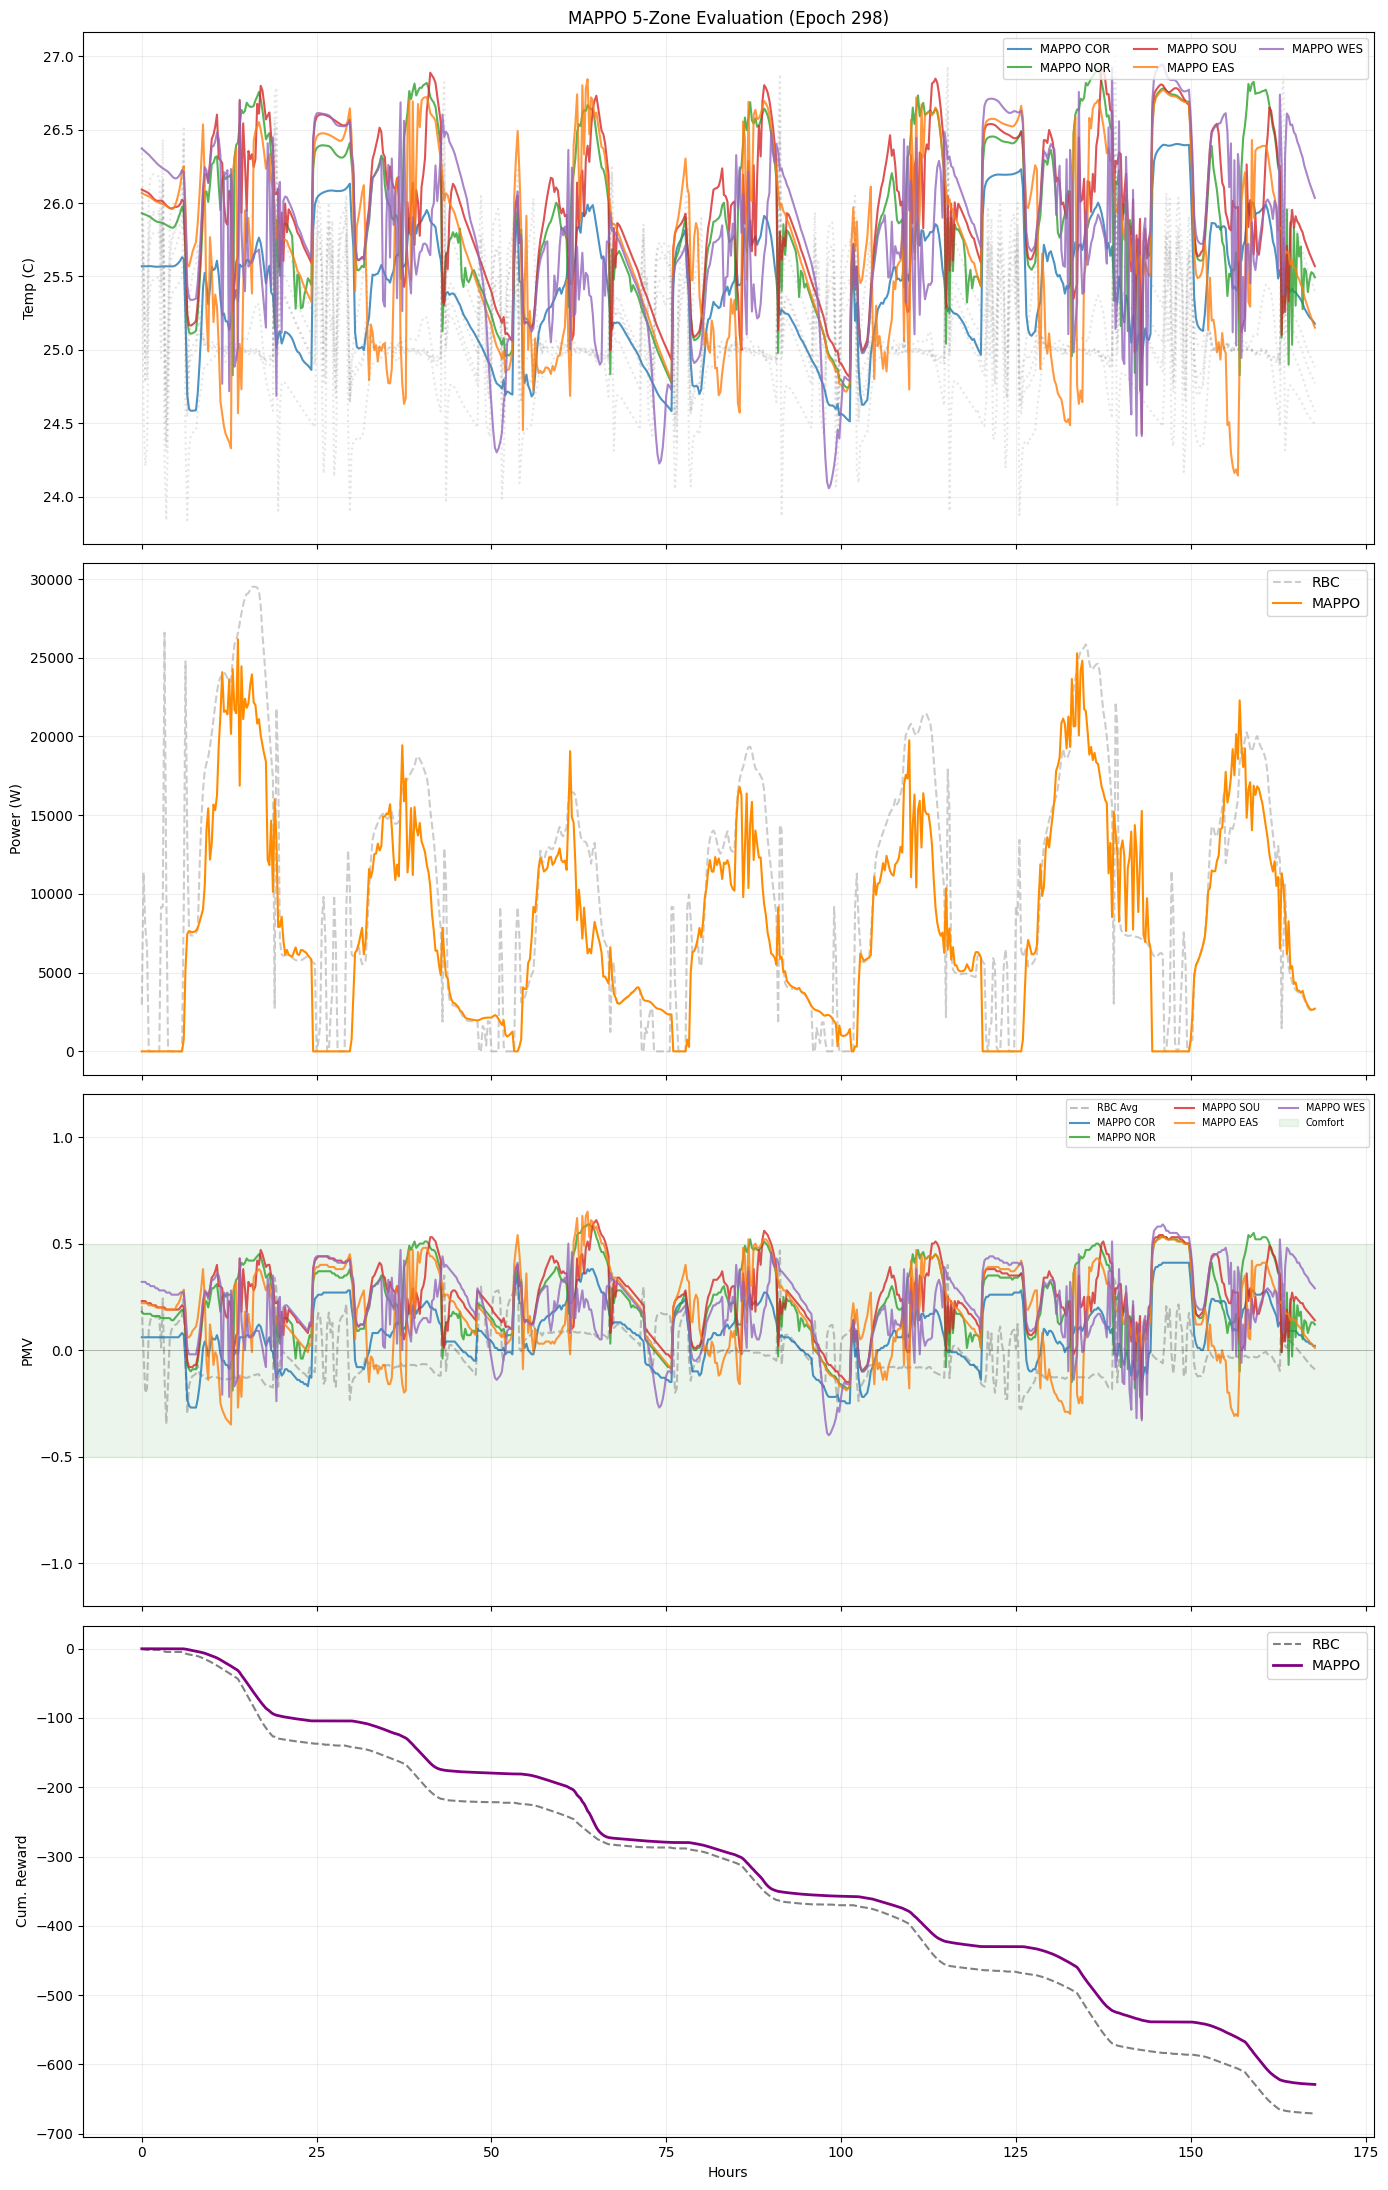

In [10]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import requests
import pandas as pd
import numpy as np
import time
import traceback
import json
import gc
import sys
import math
import matplotlib.pyplot as plt
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed

try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

# ==============================================================================
# 1. 核心辅助函数 (与原版一致)
# ==============================================================================

def safe_float(val, default=0.0):
    try:
        if val is None: return default
        f = float(val)
        return f if not (math.isnan(f) or math.isinf(f)) else default
    except: return default

def _make_request_with_retry(method, url, rank, context_msg, max_retries=5, **kwargs):
    for attempt in range(max_retries):
        try:
            kwargs.setdefault('timeout', 90)
            response = requests.request(method, url, **kwargs)
            if response.status_code == 200:
                return response.json() if response.content else {'status': 'success'}
            if response.status_code == 400 and "stop" in url:
                return {'status': 'ignored_error'}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 * (attempt + 1))
            else:
                print(f"[Rank {rank}] {context_msg} 最终失败: {e}")
    return None

def get_dynamic_clo(daily_mean_tout, params):
    t = safe_float(daily_mean_tout, 20.0)
    if t < params['temp_low']: return params['winter_clo']
    elif t > params['temp_high']: return params['summer_clo']
    else:
        ratio = (t - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

def calculate_pmv_state(t_air_k, phys_config, clo_val):
    if pmv_ppd_iso is None: return 0.0
    t_c = safe_float(t_air_k, 298.15) - 273.15
    vel = phys_config.get('air_velocity', 0.1)
    rh = phys_config.get('relative_humidity', 50.0)
    met = phys_config.get('metabolic_rate', 1.1)
    clo = safe_float(clo_val, 0.5)
    try:
        res = pmv_ppd_iso(tdb=t_c, tr=t_c, vr=vel, rh=rh, met=met, clo=clo)
        if isinstance(res, dict): val = res.get('pmv', 0.0)
        elif hasattr(res, 'pmv'): val = res.pmv
        else: val = float(res)
        return safe_float(val, 0.0)
    except: return 0.0


class ForecastProvider:
    def __init__(self, config_obj):
        self.config = config_obj
        self.data = {}
        self.start_time = config_obj.START_DAY * 24 * 3600
        self.total_horizon = (config_obj.RBC_COLLECT_DAYS + 1) * 24 * 3600

    def prefetch_all(self):
        print(f"\n[ForecastProvider] 正在预取全量数据 (Horizon: {self.total_horizon/3600:.1f}h)...")
        try:
            sel_url = f"{self.config.BOPTEST_URL}/testcases/{self.config.CASE_NAME}/select"
            res_sel = requests.post(sel_url, timeout=60).json()
            tid = res_sel['testid']
            requests.put(f"{self.config.BOPTEST_URL}/scenario/{tid}", json={'electricity_price': 'dynamic'})
            requests.put(f"{self.config.BOPTEST_URL}/initialize/{tid}",
                         json={'start_time': self.start_time, 'warmup_period': 0})
            f_payload = {'point_names': self.config.FORECAST_POINTS, 'horizon': self.total_horizon,
                         'interval': self.config.CONTROL_PERIOD}
            res_f = requests.put(f"{self.config.BOPTEST_URL}/forecast/{tid}", json=f_payload, timeout=120).json()
            if 'payload' in res_f:
                self.data = {k: np.array([x if x is not None else 0.0 for x in v])
                             for k, v in res_f['payload'].items()}
                print(f"[ForecastProvider] 预取成功。点位: {list(self.data.keys())}")
            requests.put(f"{self.config.BOPTEST_URL}/stop/{tid}")
        except Exception as e:
            print(f"[ForecastProvider] 预取失败: {e}"); raise e

    def get_local_forecast(self, current_time, point_name, horizon_steps=5):
        rel_time = current_time - self.start_time
        idx = int(max(0, rel_time // self.config.CONTROL_PERIOD))
        full_series = self.data.get(point_name)
        if full_series is None: return np.zeros(horizon_steps)
        vals = full_series[idx: idx + horizon_steps]
        if len(vals) < horizon_steps:
            padding = [vals[-1]] * (horizon_steps - len(vals)) if len(vals) > 0 else [0.0] * horizon_steps
            vals = np.concatenate([vals, padding])
        return vals


# ==============================================================================
# 2. 5-Zone Air MAPPO 环境
# ==============================================================================

class Air5ZoneMAPPOEnv:
    """
    5区域 MAPPO 环境封装。
    - step() 接收 joint_action(5,)
    - 返回全局 obs(归一化) + 共享 reward + done + info
    - get_agent_obs() 提取每个 agent 的局部观测
    """
    def __init__(self, config_obj, forecast_provider, is_validation=False, rank=0):
        self.config, self.fp, self.rank = config_obj, forecast_provider, rank
        self.url = self.config.BOPTEST_URL
        self.zones = ['cor', 'nor', 'sou', 'eas', 'wes']
        self.env_step_counter = 0
        self.debug_freq = 96

        start_day = self.config.START_DAY + 7 if is_validation else self.config.START_DAY
        self.start_time = start_day * 24 * 3600
        self.max_episode_steps = int(self.config.SIMULATION_DAYS * 24 * 3600 / self.config.CONTROL_PERIOD)

        # --- 观测空间边界 ---
        self.obs_low, self.obs_high = self._build_obs_bounds()
        self.obs_range = self.obs_high - self.obs_low
        self.obs_range[self.obs_range == 0] = 1.0

        # --- Agent 局部观测索引 (预计算) ---
        self.agent_obs_indices = {}
        for name in self.config.AGENT_NAMES:
            indices = [self.config.OBSERVATION_COLUMNS.index(col)
                       for col in self.config.AGENT_OBS_COLUMNS[name]]
            self.agent_obs_indices[name] = np.array(indices, dtype=np.int64)

        self.global_obs_dim = len(self.config.OBSERVATION_COLUMNS)
        self.agent_obs_dims = {name: len(self.config.AGENT_OBS_COLUMNS[name])
                               for name in self.config.AGENT_NAMES}

        self.testid = None
        self.history_temp = {z: deque(maxlen=5) for z in self.zones}
        self.history_act = {z: deque(maxlen=5) for z in self.zones}
        self.history_power = deque(maxlen=5)
        self.current_pmv = {z: 0.0 for z in self.zones}
        self.current_clo = 0.5

    def _build_obs_bounds(self):
        lows, highs = [], []
        for col in self.config.OBSERVATION_COLUMNS:
            if 'Price' in col: key = 'Price'
            elif 'OccMask' in col: key = 'Occ'
            elif 'HGloHor' in col: key = 'HGloHor'
            elif 'TDryBul' in col: key = 'TDryBul'
            elif 'pmv' in col: key = 'pmv'
            elif 'power_norm' in col: key = 'pow'
            elif '_act_' in col: key = 'act'
            elif '_T_' in col: key = 'T'
            else: key = col.replace('obs_', '')
            r = self.config.OBSERVATIONS_CONFIG.get(key, (0.0, 1.0))
            lows.append(r[0]); highs.append(r[1])
        return np.array(lows, dtype=np.float32), np.array(highs, dtype=np.float32)

    def _normalize_obs(self, obs_raw):
        obs = np.nan_to_num(obs_raw, nan=0.0)
        return np.nan_to_num(2.0 * (obs - self.obs_low) / self.obs_range - 1.0, nan=0.0).astype(np.float32)

    def get_agent_obs(self, global_obs_normalized, agent_name):
        return global_obs_normalized[self.agent_obs_indices[agent_name]].copy()

    def _get_observations_raw(self, y):
        cur_t = y.get('time', self.start_time)
        raw = {
            'obs_sin_time': np.sin(2 * np.pi * (cur_t % 86400) / 86400),
            'obs_cos_time': np.cos(2 * np.pi * (cur_t % 86400) / 86400),
        }

        for z in self.zones:
            z_cap = z.capitalize()
            raw[f'obs_T_{z}'] = y.get(f'hvac_reaZon{z_cap}_TZon_y', 298.15)
            for i in range(1, 5):
                raw[f'obs_T_{z}_p{i}'] = self.history_temp[z][-i] if len(self.history_temp[z]) >= i else 298.15
            raw[f'obs_pmv_{z}'] = self.current_pmv[z]
            raw[f'obs_act_{z}_p1'] = self.history_act[z][-1] if len(self.history_act[z]) > 0 else 298.15
            occ_vals = self.fp.get_local_forecast(cur_t, f'Occupancy[{z}]', 5)
            for i in range(5):
                raw[f'obs_OccMask_{z}_{i}'] = 1.0 if occ_vals[i] > 0 else 0.0

        for i in range(1, 5):
            raw[f'obs_power_norm_p{i}'] = (self.history_power[-i] / self.config.MAX_SYSTEM_POWER) \
                if len(self.history_power) >= i else 0.0

        for p in ['TDryBul', 'HGloHor', 'PriceElectricPowerDynamic']:
            vals = self.fp.get_local_forecast(cur_t, p, 5)
            p_map = 'Price' if 'Price' in p else p
            for i in range(5):
                raw[f'obs_{p_map}_{i}'] = vals[i]

        obs_np = np.array([raw.get(c, 0.0) for c in self.config.OBSERVATION_COLUMNS], dtype=np.float32)
        if self.env_step_counter % self.debug_freq == 0:
            if np.isnan(obs_np).any():
                print(f"[Rank {self.rank}][CRITICAL] NaN in Observation!")
        return obs_np

    def reset(self):
        if self.testid is None:
            res = _make_request_with_retry('post', f"{self.url}/testcases/{self.config.CASE_NAME}/select",
                                           self.rank, "select")
            self.testid = res['testid']
            _make_request_with_retry('put', f"{self.url}/step/{self.testid}", self.rank, "step",
                                     json={'step': self.config.CONTROL_PERIOD})
            _make_request_with_retry('put', f"{self.url}/scenario/{self.testid}", self.rank, "scen",
                                     json={'electricity_price': 'dynamic'})

        res_init = _make_request_with_retry('put', f"{self.url}/initialize/{self.testid}", self.rank, "init",
                                    json={'start_time': self.start_time, 'warmup_period': 7 * 24 * 3600},
                                    timeout=300)
        y = res_init['payload']
        self.current_step = 0
        self.env_step_counter = 0
        self.current_clo = 0.5
        self.history_power.clear(); self.history_power.append(0.0)

        for z in self.zones:
            self.history_temp[z].clear()
            self.history_act[z].clear()
            z_cap = z.capitalize()
            self.history_temp[z].append(y.get(f'hvac_reaZon{z_cap}_TZon_y', 298.15))
            self.history_act[z].append(298.15)
            self.current_pmv[z] = 0.0

        return self._normalize_obs(self._get_observations_raw(y))

    def step(self, joint_action):
        """joint_action: np.array(5,), 每个元素 in [-1, 1]"""
        cur_t = self.start_time + self.current_step * self.config.CONTROL_PERIOD

        # A. 动态热阻更新
        if self.current_step % 96 == 0:
            tout_f = self.fp.get_local_forecast(cur_t, 'TDryBul', 96)
            self.current_clo = get_dynamic_clo(np.mean(tout_f) - 273.15,
                                               self.config.PHYSICAL_CONFIG['clo_dynamic_params'])

        # B. 5区域动作映射
        absolute_base_k = 298.15
        u = {'hvac_oveAhu_TSupSet_u': 290.15, 'hvac_oveAhu_TSupSet_activate': 1}
        target_sets_k = []
        for i, z in enumerate(self.zones):
            z_cap = z.capitalize()
            set_k = np.clip(absolute_base_k + float(joint_action[i]) * self.config.RESIDUAL_ACTION_SCALE,
                            293.15, 303.15)
            u[f'hvac_oveZonSup{z_cap}_TZonCooSet_u'] = set_k
            u[f'hvac_oveZonSup{z_cap}_TZonCooSet_activate'] = 1
            u[f'hvac_oveZonSup{z_cap}_TZonHeaSet_u'] = self.config.FIXED_HEATING_SETPOINT
            u[f'hvac_oveZonSup{z_cap}_TZonHeaSet_activate'] = 1
            target_sets_k.append(set_k)

        # C. 环境推进
        res = _make_request_with_retry('post', f"{self.url}/advance/{self.testid}", self.rank, "adv", json=u)
        y_next = res['payload']

        # D. 功率聚合
        p_tot = (y_next.get('chi_reaPChi_y', 0) + y_next.get('chi_reaPPumDis_y', 0) +
                 y_next.get('heaPum_reaPHeaPum_y', 0) + y_next.get('heaPum_reaPPumDis_y', 0) +
                 y_next.get('hvac_reaAhu_PFanSup_y', 0) + y_next.get('hvac_reaAhu_PPumCoo_y', 0) +
                 y_next.get('hvac_reaAhu_PPumHea_y', 0))

        price = self.fp.get_local_forecast(cur_t, 'PriceElectricPowerDynamic', 1)[0]
        cost = (p_tot * self.config.CONTROL_PERIOD / 3600000.0) * price

        # E. 奖励计算
        w, n = self.config.REWARD_WEIGHTS, self.config.N_ZONES
        en_penalty = (cost / n) * w['scaler_energy']

        cm_total, sm_total = 0.0, 0.0
        for i, z in enumerate(self.zones):
            tk = y_next[f'hvac_reaZon{z.capitalize()}_TZon_y']
            self.current_pmv[z] = calculate_pmv_state(tk, self.config.PHYSICAL_CONFIG, self.current_clo)
            occ = self.fp.get_local_forecast(cur_t, f'Occupancy[{z}]', 1)[0]
            if occ > 0:
                cm_total += max(0, abs(self.current_pmv[z]) - 0.4) ** 2
            sm_total += abs(target_sets_k[i] - self.history_act[z][-1]) if len(self.history_act[z]) > 0 else 0
            self.history_temp[z].append(tk)
            self.history_act[z].append(target_sets_k[i])

        reward = -1.0 * (w['w_energy'] * en_penalty +
                         w['w_comfort'] * (cm_total / n) * w['scaler_comfort'] +
                         w['w_smooth'] * (sm_total / n) * w['scaler_smooth'])

        # F. Debug
        if self.env_step_counter % self.debug_freq == 0:
            print(f"\n>>> [Rank {self.rank}][Step {self.env_step_counter}] 5-Zone MAPPO:")
            print(f"    Actions: {[f'{float(joint_action[i]):.2f}' for i in range(5)]}")
            print(f"    PMVs: {[f'{self.current_pmv[z]:.2f}' for z in self.zones]}")
            print(f"    Reward: {reward:.3f} (E={-en_penalty*w['w_energy']:.3f}, "
                  f"C={-w['w_comfort']*(cm_total/n)*w['scaler_comfort']:.3f}, "
                  f"S={-w['w_smooth']*(sm_total/n)*w['scaler_smooth']:.3f})")

        self.env_step_counter += 1
        self.history_power.append(p_tot)
        self.current_step += 1
        done = self.current_step >= self.max_episode_steps

        info = {
            'rew_energy': w['w_energy'] * en_penalty,
            'rew_comfort': w['w_comfort'] * (cm_total / n) * w['scaler_comfort'],
            'rew_smooth': w['w_smooth'] * (sm_total / n) * w['scaler_smooth'],
            'phys_cost': cost,
            'phys_pmv_abs': np.mean([abs(v) for v in self.current_pmv.values()]),
            'phys_act_diff': sm_total / n,
        }

        return self._normalize_obs(self._get_observations_raw(y_next)), reward, done, info

    def close(self):
        if self.testid:
            _make_request_with_retry('put', f"{self.config.BOPTEST_URL}/stop/{self.testid}", self.rank, "stop")
            self.testid = None


# ==============================================================================
# 3. MAPPO 神经网络 (从双区域验证过的正确版本)
# ==============================================================================

class ActorNetwork(nn.Module):
    """
    高斯策略网络。Tanh 约束 mean 在 [-1,1]，
    log_prob 基于原始采样动作计算 (避免 clipped action 导致 ratio 爆炸)。
    """
    def __init__(self, obs_dim, action_dim=1, hidden_sizes=[256, 256]):
        super().__init__()
        layers = []
        prev_dim = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.LayerNorm(h))
            layers.append(nn.ReLU())
            prev_dim = h
        self.backbone = nn.Sequential(*layers)
        self.mean_linear = nn.Linear(prev_dim, action_dim)
        self.log_std = nn.Parameter(torch.full((action_dim,), -1.0))  # std ≈ 0.368

        for m in self.backbone:
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.mean_linear.weight, gain=0.01)
        nn.init.zeros_(self.mean_linear.bias)

    def forward(self, obs):
        features = self.backbone(obs)
        mean = torch.tanh(self.mean_linear(features))
        std = torch.clamp(self.log_std.exp(), min=0.01, max=1.0)
        return Normal(mean, std)

    def get_action(self, obs, deterministic=False):
        dist = self.forward(obs)
        if deterministic:
            action = dist.mean
        else:
            action = dist.rsample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return action, log_prob, entropy

    def evaluate_action(self, obs, action):
        dist = self.forward(obs)
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return log_prob, entropy


class CentralizedCritic(nn.Module):
    def __init__(self, global_obs_dim, hidden_sizes=[256, 256]):
        super().__init__()
        layers = []
        prev_dim = global_obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.LayerNorm(h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
        for m in self.network:
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        final = [m for m in self.network if isinstance(m, nn.Linear)][-1]
        nn.init.orthogonal_(final.weight, gain=1.0)

    def forward(self, global_obs):
        return self.network(global_obs).squeeze(-1)


# ==============================================================================
# 4. MAPPO Rollout Buffer (多环境并行)
# ==============================================================================

class MAPPORolloutBuffer:
    def __init__(self, n_steps, n_envs, n_agents, agent_obs_dims, global_obs_dim, device='cpu'):
        self.n_steps, self.n_envs, self.device = n_steps, n_envs, device
        self.ptr = 0
        self.agent_obs, self.agent_actions, self.agent_log_probs = {}, {}, {}
        for name, dim in agent_obs_dims.items():
            self.agent_obs[name] = np.zeros((n_steps, n_envs, dim), dtype=np.float32)
            self.agent_actions[name] = np.zeros((n_steps, n_envs, 1), dtype=np.float32)
            self.agent_log_probs[name] = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.global_obs = np.zeros((n_steps, n_envs, global_obs_dim), dtype=np.float32)
        self.rewards = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.values = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.dones = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.advantages = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.returns = np.zeros((n_steps, n_envs), dtype=np.float32)

    def add(self, agent_obs_dict, agent_actions_dict, agent_lp_dict, global_obs, rewards, values, dones):
        idx = self.ptr
        for name in agent_obs_dict:
            self.agent_obs[name][idx] = agent_obs_dict[name]
            self.agent_actions[name][idx] = agent_actions_dict[name]
            self.agent_log_probs[name][idx] = agent_lp_dict[name]
        self.global_obs[idx] = global_obs
        self.rewards[idx] = rewards; self.values[idx] = values; self.dones[idx] = dones
        self.ptr += 1

    def compute_gae(self, last_values, gamma=0.99, gae_lambda=0.95):
        last_gae = np.zeros(self.n_envs, dtype=np.float32)
        for t in reversed(range(self.ptr)):
            next_values = last_values if t == self.ptr - 1 else self.values[t + 1]
            next_non_terminal = 1.0 - self.dones[t]
            delta = self.rewards[t] + gamma * next_values * next_non_terminal - self.values[t]
            last_gae = delta + gamma * gae_lambda * next_non_terminal * last_gae
            self.advantages[t] = last_gae
        self.returns[:self.ptr] = self.advantages[:self.ptr] + self.values[:self.ptr]

    def get_batches(self, batch_size, agent_names):
        total = self.ptr * self.n_envs
        indices = np.random.permutation(total)
        flat_go = self.global_obs[:self.ptr].reshape(-1, self.global_obs.shape[-1])
        flat_r = self.rewards[:self.ptr].reshape(-1)
        flat_v = self.values[:self.ptr].reshape(-1)
        flat_adv = self.advantages[:self.ptr].reshape(-1)
        flat_ret = self.returns[:self.ptr].reshape(-1)
        flat_a = {}
        for name in agent_names:
            flat_a[f'obs_{name}'] = self.agent_obs[name][:self.ptr].reshape(-1, self.agent_obs[name].shape[-1])
            flat_a[f'act_{name}'] = self.agent_actions[name][:self.ptr].reshape(-1, 1)
            flat_a[f'lp_{name}'] = self.agent_log_probs[name][:self.ptr].reshape(-1)
        for start in range(0, total, batch_size):
            end = min(start + batch_size, total)
            bi = indices[start:end]
            batch = {
                'global_obs': torch.FloatTensor(flat_go[bi]).to(self.device),
                'advantages': torch.FloatTensor(flat_adv[bi]).to(self.device),
                'returns': torch.FloatTensor(flat_ret[bi]).to(self.device),
            }
            for name in agent_names:
                batch[f'obs_{name}'] = torch.FloatTensor(flat_a[f'obs_{name}'][bi]).to(self.device)
                batch[f'act_{name}'] = torch.FloatTensor(flat_a[f'act_{name}'][bi]).to(self.device)
                batch[f'lp_{name}'] = torch.FloatTensor(flat_a[f'lp_{name}'][bi]).to(self.device)
            yield batch

    def reset(self):
        self.ptr = 0


# ==============================================================================
# 5. MAPPO Trainer
# ==============================================================================

class MAPPOTrainer:
    def __init__(self, config_obj, envs, device=None):
        self.config = config_obj
        self.envs = envs
        self.n_envs = len(envs)
        self.params = config_obj.MAPPO_PARAMS
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"[MAPPO] Device: {self.device}, Envs: {self.n_envs}")

        ref_env = envs[0]
        torch.manual_seed(config_obj.SEED); np.random.seed(config_obj.SEED)

        self.actors, self.actor_optimizers = {}, {}
        for name in config_obj.AGENT_NAMES:
            obs_dim = ref_env.agent_obs_dims[name]
            actor = ActorNetwork(obs_dim, 1, self.params['actor_arch']).to(self.device)
            opt = optim.Adam(actor.parameters(), lr=self.params['learning_rate_actor'], eps=1e-5)
            self.actors[name] = actor; self.actor_optimizers[name] = opt
            print(f"[MAPPO] Actor '{name}': obs_dim={obs_dim}, params={sum(p.numel() for p in actor.parameters())}")

        self.critic = CentralizedCritic(ref_env.global_obs_dim, self.params['critic_arch']).to(self.device)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=self.params['learning_rate_critic'], eps=1e-5)
        print(f"[MAPPO] Critic: global_obs_dim={ref_env.global_obs_dim}, params={sum(p.numel() for p in self.critic.parameters())}")

        self.buffer = MAPPORolloutBuffer(self.params['n_steps'], self.n_envs, config_obj.N_AGENTS,
                                         ref_env.agent_obs_dims, ref_env.global_obs_dim, self.device)

        self.total_steps, self.epoch_count, self.best_mean_reward = 0, 0, -np.inf
        self.training_log, self.epoch_infos = [], []

        total_updates = config_obj.TOTAL_DRL_EPOCHS
        self.actor_schedulers = {
            name: optim.lr_scheduler.LambdaLR(
                self.actor_optimizers[name],
                lr_lambda=lambda ep, tu=total_updates: max(0.1, 1.0 - 0.9 * ep / tu)
            ) for name in config_obj.AGENT_NAMES
        }
        self.critic_scheduler = optim.lr_scheduler.LambdaLR(
            self.critic_optimizer, lr_lambda=lambda ep: max(0.1, 1.0 - 0.9 * ep / total_updates))

        self.save_dir = config_obj.LOG_DIRS['models_drl']
        self.log_path = os.path.join(self.save_dir, 'mappo_training_log.csv')
        if os.path.exists(self.log_path):
            try:
                edf = pd.read_csv(self.log_path)
                self.training_log = edf.to_dict('records')
                self.epoch_count = len(self.training_log)
                if not edf.empty: self.best_mean_reward = edf['MeanReward'].max()
                print(f"[Log] 接续 Epoch {self.epoch_count + 1}。历史最高: {self.best_mean_reward:.3f}")
            except: pass

    @staticmethod
    def _env_step_worker(env, action):
        return env.step(action)

    @staticmethod
    def _env_reset_worker(env):
        return env.reset()

    def _collect_rollout(self, global_obs_all):
        self.buffer.reset()
        episode_rewards = []
        current_ep_rewards = np.zeros(self.n_envs, dtype=np.float32)
        n_agents = len(self.config.AGENT_NAMES)

        with ThreadPoolExecutor(max_workers=self.n_envs) as executor:
            for step in range(self.params['n_steps']):
                agent_obs_batch, agent_actions_batch, agent_lp_batch = {}, {}, {}
                joint_actions = np.zeros((self.n_envs, n_agents), dtype=np.float32)

                with torch.no_grad():
                    global_obs_t = torch.FloatTensor(global_obs_all).to(self.device)
                    values = self.critic(global_obs_t).cpu().numpy()

                    for i, name in enumerate(self.config.AGENT_NAMES):
                        local_obs_list = [self.envs[e].get_agent_obs(global_obs_all[e], name)
                                          for e in range(self.n_envs)]
                        local_obs_np = np.array(local_obs_list, dtype=np.float32)
                        local_obs_t = torch.FloatTensor(local_obs_np).to(self.device)
                        actions, log_probs, _ = self.actors[name].get_action(local_obs_t, deterministic=False)
                        act_np = actions.cpu().numpy()
                        lp_np = log_probs.cpu().numpy()
                        agent_obs_batch[name] = local_obs_np
                        agent_actions_batch[name] = act_np  # 原始动作存 buffer
                        agent_lp_batch[name] = lp_np
                        joint_actions[:, i] = np.clip(act_np.flatten(), -1.0, 1.0)  # clip 后发 env

                futures = {executor.submit(self._env_step_worker, self.envs[e], joint_actions[e]): e
                           for e in range(self.n_envs)}
                rewards = np.zeros(self.n_envs, dtype=np.float32)
                dones = np.zeros(self.n_envs, dtype=np.float32)
                next_obs_all = np.zeros_like(global_obs_all)
                step_infos = [None] * self.n_envs

                for future in as_completed(futures):
                    e = futures[future]
                    nobs, rew, done, info = future.result()
                    rewards[e] = rew; dones[e] = float(done)
                    next_obs_all[e] = nobs; step_infos[e] = info
                    current_ep_rewards[e] += rew

                reset_envs = [e for e in range(self.n_envs) if dones[e] > 0.5]
                if reset_envs:
                    rf = {executor.submit(self._env_reset_worker, self.envs[e]): e for e in reset_envs}
                    for future in as_completed(rf):
                        e = rf[future]
                        next_obs_all[e] = future.result()
                        episode_rewards.append(current_ep_rewards[e])
                        current_ep_rewards[e] = 0.0

                for e in range(self.n_envs):
                    self.epoch_infos.append(step_infos[e])

                self.buffer.add(agent_obs_batch, agent_actions_batch, agent_lp_batch,
                                global_obs_all, rewards, values, dones)
                self.total_steps += self.n_envs
                global_obs_all = next_obs_all

        with torch.no_grad():
            last_v = self.critic(torch.FloatTensor(global_obs_all).to(self.device)).cpu().numpy()
        self.buffer.compute_gae(last_v, self.params['gamma'], self.params['gae_lambda'])
        return global_obs_all, episode_rewards

    def _update(self):
        clip_range = self.params['clip_range']
        ent_coef = self.params['ent_coef']
        max_gn = self.params['max_grad_norm']
        t_actor_loss = {n: 0.0 for n in self.config.AGENT_NAMES}
        t_critic_loss, t_entropy, n_up = 0.0, 0.0, 0

        for _ in range(self.params['n_epochs']):
            for batch in self.buffer.get_batches(self.params['batch_size'], self.config.AGENT_NAMES):
                nv = self.critic(batch['global_obs'])
                vl = 0.5 * ((nv - batch['returns']) ** 2).mean()
                self.critic_optimizer.zero_grad(); vl.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), max_gn)
                self.critic_optimizer.step(); t_critic_loss += vl.item()

                adv = batch['advantages']
                adv = (adv - adv.mean()) / (adv.std() + 1e-8)

                for name in self.config.AGENT_NAMES:
                    new_lp, ent = self.actors[name].evaluate_action(batch[f'obs_{name}'], batch[f'act_{name}'])
                    ratio = torch.exp(new_lp - batch[f'lp_{name}'])
                    s1 = ratio * adv
                    s2 = torch.clamp(ratio, 1.0 - clip_range, 1.0 + clip_range) * adv
                    pl = -torch.min(s1, s2).mean()
                    el = -ent.mean()
                    al = pl + ent_coef * el
                    self.actor_optimizers[name].zero_grad(); al.backward()
                    nn.utils.clip_grad_norm_(self.actors[name].parameters(), max_gn)
                    self.actor_optimizers[name].step()
                    t_actor_loss[name] += al.item(); t_entropy += (-el.item())
                n_up += 1

        for name in self.config.AGENT_NAMES: self.actor_schedulers[name].step()
        self.critic_scheduler.step()
        na = len(self.config.AGENT_NAMES)
        return {
            'actor_losses': {k: v / max(n_up, 1) for k, v in t_actor_loss.items()},
            'critic_loss': t_critic_loss / max(n_up, 1),
            'entropy': t_entropy / max(n_up * na, 1),
            'lr_actor': self.actor_optimizers[self.config.AGENT_NAMES[0]].param_groups[0]['lr'],
            'lr_critic': self.critic_optimizer.param_groups[0]['lr'],
        }

    def _log_epoch(self, ep_rewards, update_info, duration):
        self.epoch_count += 1
        mean_reward = np.mean(ep_rewards) if ep_rewards else -9999
        if self.epoch_infos:
            avg_cost = np.mean([x['phys_cost'] for x in self.epoch_infos])
            avg_pmv = np.mean([x['phys_pmv_abs'] for x in self.epoch_infos])
            avg_act = np.mean([x['phys_act_diff'] for x in self.epoch_infos])
            r_en = np.mean([x['rew_energy'] for x in self.epoch_infos])
            r_cm = np.mean([x['rew_comfort'] for x in self.epoch_infos])
            r_sm = np.mean([x['rew_smooth'] for x in self.epoch_infos])
            tp = max(1e-6, r_en + r_cm + r_sm)
            vio = sum(1 for x in self.epoch_infos if x['phys_pmv_abs'] > 0.5) / len(self.epoch_infos)

            print(f"\n[MAPPO Epoch {self.epoch_count} | 5 Zones | {self.n_envs} Envs]")
            print("-" * 80)
            print(f"| Energy         | $ {avg_cost:.4f}   | - {r_en:.3f}  ({r_en/tp*100:.1f}%)      |")
            print(f"| Comfort        | {avg_pmv:.3f} (PMV) | - {r_cm:.3f}  ({r_cm/tp*100:.1f}%)      |")
            print(f"| Smoothness     | {avg_act:.3f} (K)   | - {r_sm:.3f}  ({r_sm/tp*100:.1f}%)      |")
            print("-" * 80)
            print(f"| TOTAL REWARD   | {mean_reward:.3f}  | Comfort Vio: {vio*100:.1f}%            |")
            al_str = ", ".join([f"{n}={update_info['actor_losses'][n]:.4f}" for n in self.config.AGENT_NAMES])
            print(f"| Actor Losses   | {al_str} |")
            print(f"| Critic={update_info['critic_loss']:.4f} | Entropy={update_info['entropy']:.4f} "
                  f"| LR_a={update_info['lr_actor']:.6f} | {duration:.1f}s |")
            print("-" * 80)
            self.epoch_infos = []

        if mean_reward > self.best_mean_reward:
            self.best_mean_reward = mean_reward
            self.save_checkpoint('best')
            print(f"[*] New best: {mean_reward:.3f}")
        if self.epoch_count % 50 == 0: self.save_checkpoint(f'epoch_{self.epoch_count}')

        self.training_log.append({'Epoch': self.epoch_count, 'MeanReward': mean_reward,
                                  'Time': duration, 'Steps': self.total_steps,
                                  'CriticLoss': update_info['critic_loss'], 'Entropy': update_info['entropy']})
        pd.DataFrame(self.training_log).to_csv(self.log_path, index=False)

    def save_checkpoint(self, tag='latest'):
        ckpt = {'epoch': self.epoch_count, 'total_steps': self.total_steps,
                'best_mean_reward': self.best_mean_reward,
                'critic_state_dict': self.critic.state_dict(),
                'critic_optimizer': self.critic_optimizer.state_dict()}
        for name in self.config.AGENT_NAMES:
            ckpt[f'actor_{name}_state_dict'] = self.actors[name].state_dict()
            ckpt[f'actor_{name}_optimizer'] = self.actor_optimizers[name].state_dict()
        path = os.path.join(self.save_dir, f'mappo_{tag}.pt')
        torch.save(ckpt, path)
        print(f"[Checkpoint] Saved: {path}")

    def load_checkpoint(self, tag='best'):
        path = os.path.join(self.save_dir, f'mappo_{tag}.pt')
        if not os.path.exists(path):
            print(f"[Warning] Not found: {path}"); return False
        ckpt = torch.load(path, map_location=self.device, weights_only=False)
        self.critic.load_state_dict(ckpt['critic_state_dict'])
        self.critic_optimizer.load_state_dict(ckpt['critic_optimizer'])
        for name in self.config.AGENT_NAMES:
            self.actors[name].load_state_dict(ckpt[f'actor_{name}_state_dict'])
            self.actor_optimizers[name].load_state_dict(ckpt[f'actor_{name}_optimizer'])
        self.epoch_count = ckpt.get('epoch', 0)
        self.total_steps = ckpt.get('total_steps', 0)
        self.best_mean_reward = ckpt.get('best_mean_reward', -np.inf)
        print(f"[Checkpoint] Loaded: {path} (Epoch {self.epoch_count})")
        return True

    def train(self):
        target = self.config.TOTAL_DRL_EPOCHS
        remaining = target - self.epoch_count
        if remaining <= 0:
            print(f"[Finished] {self.epoch_count}/{target} done."); return
        spe = self.params['n_steps'] * self.n_envs
        print(f"\n{'='*60}\n  MAPPO 5-Zone: {remaining} epochs, {spe} steps/epoch\n{'='*60}\n")

        global_obs_all = np.zeros((self.n_envs, self.envs[0].global_obs_dim), dtype=np.float32)
        with ThreadPoolExecutor(max_workers=self.n_envs) as ex:
            fs = {ex.submit(self._env_reset_worker, self.envs[e]): e for e in range(self.n_envs)}
            for f in as_completed(fs): global_obs_all[fs[f]] = f.result()

        try:
            for _ in range(remaining):
                t0 = time.time()
                global_obs_all, ep_rew = self._collect_rollout(global_obs_all)
                ui = self._update()
                self._log_epoch(ep_rew, ui, time.time() - t0)
        except KeyboardInterrupt:
            print("\n[Interrupted]"); self.save_checkpoint('interrupted')
        except Exception as e:
            print(f"\n[Error] {e}"); traceback.print_exc(); self.save_checkpoint('error_recovery')
        finally:
            self.save_checkpoint('latest')
            print(f"\n[MAPPO] Done. {self.epoch_count} epochs, {self.total_steps} steps.")


# ==============================================================================
# 6. 评估逻辑
# ==============================================================================

def run_mappo_evaluation(trainer, epoch_idx, config_obj, fp, is_validation=True):
    print(f"\n[Eval] 5-Zone MAPPO Evaluation (Epoch {epoch_idx})...")
    eval_env = Air5ZoneMAPPOEnv(config_obj, fp, is_validation=is_validation, rank=-1)
    zones = eval_env.zones

    rbc_path = os.path.join(config_obj.LOG_DIRS['data_rbc'], 'rbc_validation_air_5zone.csv')
    if not os.path.exists(rbc_path):
        print(f"[Error] RBC data not found: {rbc_path}"); eval_env.close(); return
    df_rbc = pd.read_csv(rbc_path)

    global_obs = eval_env.reset()
    done, logs = False, []
    while not done:
        joint_action = np.zeros(5, dtype=np.float32)
        with torch.no_grad():
            for i, name in enumerate(config_obj.AGENT_NAMES):
                lo = eval_env.get_agent_obs(global_obs, name)
                lot = torch.FloatTensor(lo).unsqueeze(0).to(trainer.device)
                action, _, _ = trainer.actors[name].get_action(lot, deterministic=True)
                joint_action[i] = np.clip(action.cpu().numpy().flatten()[0], -1.0, 1.0)
        global_obs, reward, done, info = eval_env.step(joint_action)
        row = {'reward_step': reward, 'power_total': eval_env.history_power[-1], 'phys_cost': info['phys_cost']}
        for z in zones:
            row[f'temp_{z}'] = eval_env.history_temp[z][-1] - 273.15
            row[f'pmv_{z}'] = eval_env.current_pmv[z]
        logs.append(row)

    df_drl = pd.DataFrame(logs)
    ml = min(len(df_drl), len(df_rbc))
    df_drl = df_drl.iloc[:ml].copy(); df_rbc_s = df_rbc.iloc[:ml].copy()
    time_h = np.arange(ml) * config_obj.CONTROL_PERIOD / 3600
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd']

    fig, axes = plt.subplots(4, 1, figsize=(14, 22), sharex=True)

    for i, z in enumerate(zones):
        axes[0].plot(time_h, df_rbc_s[f'temp_{z}'], ':', color='gray', alpha=0.2)
        axes[0].plot(time_h, df_drl[f'temp_{z}'], color=colors[i], label=f'MAPPO {z.upper()}', alpha=0.8)
    axes[0].set_ylabel('Temp (C)'); axes[0].legend(loc='upper right', ncol=3, fontsize='small'); axes[0].grid(True, alpha=0.2)
    axes[0].set_title(f'MAPPO 5-Zone Evaluation (Epoch {epoch_idx})')

    axes[1].plot(time_h, df_rbc_s['power_total'], '--', color='gray', alpha=0.4, label='RBC')
    axes[1].plot(time_h, df_drl['power_total'], color='darkorange', label='MAPPO')
    axes[1].set_ylabel('Power (W)'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

    rbc_pmv_avg = df_rbc_s[[f'pmv_{z}' for z in zones]].mean(axis=1)
    axes[2].plot(time_h, rbc_pmv_avg, '--', color='gray', alpha=0.5, label='RBC Avg')
    for i, z in enumerate(zones):
        axes[2].plot(time_h, df_drl[f'pmv_{z}'], color=colors[i], alpha=0.8, label=f'MAPPO {z.upper()}')
    axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.08, label='Comfort')
    axes[2].axhline(0, color='black', linewidth=0.5, alpha=0.3)
    axes[2].set_ylabel('PMV'); axes[2].set_ylim(-1.2, 1.2)
    axes[2].legend(loc='upper right', ncol=3, fontsize='x-small'); axes[2].grid(True, alpha=0.2)

    axes[3].plot(time_h, df_rbc_s['reward'].cumsum(), '--', color='gray', label='RBC')
    axes[3].plot(time_h, df_drl['reward_step'].cumsum(), color='purple', linewidth=2, label='MAPPO')
    axes[3].set_ylabel('Cum. Reward'); axes[3].set_xlabel('Hours'); axes[3].legend(); axes[3].grid(True, alpha=0.2)

    plt.tight_layout()
    pp = os.path.join(config_obj.LOG_DIRS['results_comparison'], f"mappo_eval_epoch_{epoch_idx}.png")
    plt.savefig(pp, dpi=300); print(f"[Plot] Saved: {pp}")

    sav = (1 - df_drl['phys_cost'].sum() / max(df_rbc_s['cost'].sum(), 1e-6)) * 100
    dr = df_drl['reward_step'].sum(); rr = df_rbc_s['reward'].sum()
    print(f"\n{'='*50}\n  MAPPO 5-Zone Performance (Epoch {epoch_idx})")
    print(f"  Energy Savings: {sav:.2f}%")
    print(f"  MAPPO Reward: {dr:.2f} | RBC Reward: {rr:.2f}")
    print(f"  Improvement: {((dr-rr)/abs(rr))*100:.2f}%\n{'='*50}")
    eval_env.close()


# ==============================================================================
# 7. 主入口
# ==============================================================================

N_PARALLEL_ENVS = 4

def main_mappo_training():
    fp = ForecastProvider(config); fp.prefetch_all()
    print(f"\n[System] Creating {N_PARALLEL_ENVS} parallel envs...")
    envs = [Air5ZoneMAPPOEnv(config, fp, is_validation=False, rank=i) for i in range(N_PARALLEL_ENVS)]

    trainer = MAPPOTrainer(config, envs)
    bp = os.path.join(config.LOG_DIRS['models_drl'], 'mappo_best.pt')
    lp = os.path.join(config.LOG_DIRS['models_drl'], 'mappo_latest.pt')
    if os.path.exists(bp): trainer.load_checkpoint('best')
    elif os.path.exists(lp): trainer.load_checkpoint('latest')

    try: trainer.train()
    finally:
        for env in envs: env.close()

    if os.path.exists(bp):
        print(f"\n[*] Loading best for final eval...")
        trainer.load_checkpoint('best')
        run_mappo_evaluation(trainer, trainer.epoch_count, config, fp)

if __name__ == '__main__':
    main_mappo_training()